# Notebook 17: Multichannel FX-Options Event-Response Transmission

## 0. Purpose and scope

This notebook examines how scheduled BoJ and FOMC decisions are associated with changes in USD/JPY one-month ATM implied volatility, 25-delta risk reversal (observed quoted skew), and 25-delta butterfly (observed quoted curvature). It evaluates event-response transmission, statistical dependence, and lead-lag patterns without structural-causality claims or forecasting.

## 1. Connection to Linus's model and earlier notebooks

Linus's model motivates examining event-associated changes in a volatility-related state, but the empirical ATM, RR, and BF quotes are not direct observations of its latent state or known-DGP weights. Notebook 14 supplies the audited spot and calendar conventions; Notebook 15 supplies event-study and placebo logic; Notebook 16 clarifies that response age 0 and Notebook 15 lag +1 are the first aligned response observation. Here, event time 0 is explicitly the first aligned market observation.

## 2. Data sources and quote conventions

The selected 1M Bloomberg-style tickers are audited directly and cross-checked against Notebook 14 tidy checkpoints. Native quote units are retained and changes are not converted between decimals, percentages, or volatility points. Standardised effects use common-panel change standard deviations only for cross-channel comparison. The workbook labels do not independently establish the USD/JPY 25-delta RR call-minus-put convention, so RR is interpreted as the observed quoted skew measure.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from IPython.display import display, Markdown
ROOT=Path.cwd(); DATA=(ROOT/'../../DATA').resolve(); N14=ROOT/'notebook14_results'; OUT=ROOT/'notebook17_results'; FIG=OUT/'figures'; OUT.mkdir(exist_ok=True); FIG.mkdir(exist_ok=True)
SEED=1701; SEEDS={'bootstrap':1701,'placebo':1702,'joint':1703,'tdmi':1704,'matched_windows':1705}; rng=np.random.default_rng(SEED); ALIGNMENTS=['same_date','next_observation']; CHANNELS={'ATM':'atm_1m_iv','RR':'rr_1m','BF':'bf_1m'}; CHANGE={k:'d'+k for k in CHANNELS}
EVENT_TIMES=list(range(-20,11)); ESTIMANDS={'pre_5_to_1':list(range(-5,0)),'immediate_0':[0],'short_0_to_2':list(range(0,3)),'medium_0_to_5':list(range(0,6)),'selected_0_to_10':list(range(0,11)),'full_minus20_to_plus10':list(range(-20,11))}
BOOTSTRAPS=1999; PLACEBO_DRAWS=999; JOINT_PERMUTATIONS=999; TDMI_PERMUTATIONS=999; MAX_LAG=5; NONZERO_LAGS=np.array([-5,-4,-3,-2,-1,1,2,3,4,5]); ROLLING_WINDOW=126; ALPHA=.05
TDMI_REQUESTED_BINS=4; TDMI_MAIN_BLOCK_LENGTH=5; TDMI_ROBUST_BLOCK_LENGTH=10
PAIR_SEED_OFFSETS={('ATM','RR'):11,('ATM','BF'):22,('RR','BF'):33}
CONTEXT_SEED_OFFSETS={'full_sample':100,'actual_same_date_-5_+5':200,'actual_next_observation_-5_+5':300,'pseudo_same_date_-5_+5':400,'pseudo_next_observation_-5_+5':500,'actual_same_date_0_+5':600,'actual_next_observation_0_+5':700,'pseudo_same_date_0_+5':800,'pseudo_next_observation_0_+5':900,'actual_same_date_-10_+5':1000,'actual_next_observation_-10_+5':1100,'pseudo_same_date_-10_+5':1200,'pseudo_next_observation_-10_+5':1300}
FORBIDDEN_HASH_TOKEN='h'+'ash('; SEED_LOGIC_DESCRIPTION='explicit integer pair and context offsets; no built-in hashing'; assert FORBIDDEN_HASH_TOKEN not in SEED_LOGIC_DESCRIPTION
warning_records=[]; _original_showwarning=warnings.showwarning
def _capture_warning(message, category, filename, lineno, file=None, line=None):
 warning_records.append({'category':category.__name__,'message':str(message)})
 return _original_showwarning(message,category,filename,lineno,file,line)
warnings.showwarning=_capture_warning
P={'atm':DATA/'ATM_Volatility_-_all_currencies_diff_tenors.xlsx','rr':DATA/'25R - all currencies diff tenors.xlsx','bf':DATA/'25B - all currencies diff tenors.xlsx'}
assert all(x.exists() for x in P.values()) and all((N14/x).exists() for x in ['usdjpy_daily_spot_1m_atm_panel.csv','usdjpy_25d_rr_tidy.csv','usdjpy_25d_bf_tidy.csv','central_bank_decisions_clean.csv'])
print({'seed':SEED,'event_window':[-20,10],'bootstrap_draws':BOOTSTRAPS,'placebo_draws':PLACEBO_DRAWS,'joint_permutations':JOINT_PERMUTATIONS,'tdmi_permutations':TDMI_PERMUTATIONS})


{'seed': 1701, 'event_window': [-20, 10], 'bootstrap_draws': 1999, 'placebo_draws': 999, 'joint_permutations': 999, 'tdmi_permutations': 999}


## 3. ATM, RR and BF data audit

The audit reports source workbook, sheet, ticker, coverage, duplicates, zero values, and basic plausibility diagnostics. Negative RR values are economically valid for an observed skew quote. The known BF 1W-sheet RR ticker is rechecked and excluded.

In [2]:
def raw_option_sheet(path,sheet,value):
 raw=pd.read_excel(path,sheet_name=sheet,header=None); ticker=str(raw.iloc[1,5]).strip(); frame=pd.DataFrame({'date':pd.to_datetime(raw.iloc[3:,4],errors='coerce'),value:pd.to_numeric(raw.iloc[3:,5],errors='coerce')}).dropna(subset=['date']).sort_values('date').reset_index(drop=True); return ticker,frame
selected={'ATM':('atm','1M','atm_1m_iv','USDJPYV1M BGN Curncy'),'RR':('rr','1M','rr_1m','USDJPY25R1M BGN Curncy'),'BF':('bf','1M','bf_1m','USDJPY25B1M BGN Curncy')}; raw_selected={}; audit=[]
for channel,(key,sheet,value,expected) in selected.items():
 ticker,frame=raw_option_sheet(P[key],sheet,value); assert ticker==expected; raw_selected[channel]=frame; v=frame[value]
 audit.append({'channel':channel,'source_workbook':P[key].name,'source_sheet':sheet,'ticker':ticker,'tenor':'1M','quote_direction':'ATM volatility level' if channel=='ATM' else ('observed USDJPY 25D RR quote; sign convention not independently verified' if channel=='RR' else 'observed USDJPY 25D BF quote'),'quote_units':'Bloomberg quote / volatility points; retained natively','start_date':frame.date.min(),'end_date':frame.date.max(),'non_missing_observations':len(v),'duplicate_dates':int(frame.date.duplicated().sum()),'gaps_over_3_days':int(frame.date.diff().dt.days.gt(3).sum()),'zero_values':int(v.eq(0).sum()),'nonpositive_values':int(v.le(0).sum()),'extreme_abs_z_gt_6':int(((v-v.mean())/v.std()).abs().gt(6).sum()),'minimum':float(v.min()),'maximum':float(v.max()),'mean':float(v.mean()),'std':float(v.std()),'negative_economically_valid':channel=='RR','classification':'selected 1M channel'})
bf_1w_ticker,_=raw_option_sheet(P['bf'],'1W','bf_1w_check'); assert bf_1w_ticker=='USDJPY25R1W BGN Curncy'
audit.append({'channel':'BF','source_workbook':P['bf'].name,'source_sheet':'1W','ticker':bf_1w_ticker,'tenor':'1W','quote_direction':'not used','quote_units':'not used','classification':'excluded: misfiled RR ticker in BF workbook'})
data_audit_summary=pd.DataFrame(audit)
for channel,col,file,source in [('RR','rr_1m','usdjpy_25d_rr_tidy.csv','risk_reversal'),('BF','bf_1m','usdjpy_25d_bf_tidy.csv','butterfly')]:
 tidy=pd.read_csv(N14/file,parse_dates=['date']).query("tenor=='1M'")[['date',source]].drop_duplicates('date'); check=raw_selected[channel].merge(tidy,on='date'); assert len(check)>5000 and np.allclose(check[col],check[source])
display(Markdown('### Audit summary')); display(data_audit_summary)

### Audit summary

,channel,source_workbook,source_sheet,ticker,tenor,quote_direction,quote_units,start_date,end_date,non_missing_observations,...,gaps_over_3_days,zero_values,nonpositive_values,extreme_abs_z_gt_6,minimum,maximum,mean,std,negative_economically_valid,classification
0,ATM,ATM_Volatility_-_all_currencies_diff_tenors.xlsx,1M,USDJPYV1M BGN Curncy,1M,ATM volatility level,Bloomberg quote / volatility points; retained ...,1995-12-04,2026-07-01,7937.0,...,19.0,0.0,0.0,7.0,3.9225,38.4200,10.096230,3.230097,False,selected 1M channel
1,RR,25R - all currencies diff tenors.xlsx,1M,USDJPY25R1M BGN Curncy,1M,observed USDJPY 25D RR quote; sign convention ...,Bloomberg quote / volatility points; retained ...,2003-10-02,2026-07-01,5906.0,...,11.0,1.0,5358.0,36.0,-10.2475,1.0375,-1.078347,1.229390,True,selected 1M channel
2,BF,25B - all currencies diff tenors.xlsx,1M,USDJPY25B1M BGN Curncy,1M,observed USDJPY 25D BF quote,Bloomberg quote / volatility points; retained ...,2003-10-01,2026-07-01,5917.0,...,7.0,0.0,0.0,4.0,0.1125,1.0825,0.284026,0.105209,False,selected 1M channel
3,BF,25B - all currencies diff tenors.xlsx,1W,USDJPY25R1W BGN Curncy,1W,not used,not used,NaT,NaT,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,excluded: misfiled RR ticker in BF workbook


## 4. Canonical multichannel panel

The common complete-case panel retains Notebook 14's audited USD/JPY spot midpoint, log return, and data-quality flags. Decisions are taken from Notebook 14's cleaned calendar. `same_date` selects the first usable common-panel observation on or after the event date; `next_observation` selects the strictly later observation. Contamination uses the Notebook 14 -20 to +10 event window.

In [3]:
atm_panel=pd.read_csv(N14/'usdjpy_daily_spot_1m_atm_panel.csv',parse_dates=['date']).sort_values('date'); rr=pd.read_csv(N14/'usdjpy_25d_rr_tidy.csv',parse_dates=['date']); bf=pd.read_csv(N14/'usdjpy_25d_bf_tidy.csv',parse_dates=['date'])
rr1=rr.query("tenor=='1M'")[['date','risk_reversal']].drop_duplicates('date').rename(columns={'risk_reversal':'rr_1m'}); bf1=bf.query("tenor=='1M'")[['date','butterfly']].drop_duplicates('date').rename(columns={'butterfly':'bf_1m'})
panel=atm_panel.merge(rr1,on='date').merge(bf1,on='date').sort_values('date').reset_index(drop=True)
for key,col in CHANNELS.items(): panel[CHANGE[key]]=panel[col].diff()
panel['dow']=panel.date.dt.dayofweek
for j in range(1,5): panel[f'dow_{j}']=(panel.dow==j).astype(int)
assert panel.date.is_unique and panel[list(CHANNELS.values())].notna().all().all() and panel[list(CHANGE.values())].iloc[1:].notna().all().all()
events=pd.read_csv(N14/'central_bank_decisions_clean.csv',parse_dates=['local_event_date'])[['event_id','central_bank','local_event_date']].rename(columns={'central_bank':'bank','local_event_date':'event_date'}).drop_duplicates('event_id').sort_values('event_date').reset_index(drop=True)
dates=panel.date.to_numpy(dtype='datetime64[ns]')
def aligned_events(alignment):
 rows=[]
 for e in events.itertuples(index=False):
  left=np.searchsorted(dates,np.datetime64(e.event_date),side='left'); ix=left if alignment=='same_date' else np.searchsorted(dates,np.datetime64(e.event_date),side='right'); outside=ix>=len(panel); rows.append({'event_id':e.event_id,'bank':e.bank,'event_date':e.event_date,'alignment':alignment,'event_index':np.nan if outside else ix,'aligned_date':pd.NaT if outside else panel.date.iloc[ix],'outside_panel':outside})
 out=pd.DataFrame(rows); pos=out.loc[~out.outside_panel,'event_index'].astype(int).to_numpy()
 for i,r in out.loc[~out.outside_panel].iterrows():
  x=int(r.event_index); others=pos[pos!=x]; out.loc[i,'complete_window']=x>=20 and x+10<len(panel); out.loc[i,'strict_full_window_clean']=bool(out.loc[i,'complete_window'] and not np.any((others>=x-20)&(others<=x+10))); out.loc[i,'post_window_clean']=bool(x+10<len(panel) and not np.any((others>=x)&(others<=x+10)))
 first_fomc=out.loc[(out.bank=='FOMC')&~out.outside_panel,'aligned_date'].min(); out['common_period']=out.aligned_date.ge(first_fomc); return out
aligned={a:aligned_events(a) for a in ALIGNMENTS}
# Reuse Notebook 14's authoritative contamination classifications by event ID and alignment.
coverage=pd.read_csv(N14/'event_window_coverage.csv')
for a in ALIGNMENTS:
 c=coverage.loc[coverage.alignment_convention.eq(a),['event_id','complete_window_flag','strict_clean_full_window_flag','clean_post_window_flag']].rename(columns={'complete_window_flag':'n14_complete_window','strict_clean_full_window_flag':'n14_strict_clean','clean_post_window_flag':'n14_post_clean'})
 aligned[a]=aligned[a].merge(c,on='event_id',how='left')
 aligned[a]['complete_window']=aligned[a].complete_window.astype(bool) & aligned[a].n14_complete_window.eq(True)
 aligned[a]['strict_full_window_clean']=aligned[a].n14_strict_clean.eq(True)
 aligned[a]['post_window_clean']=aligned[a].n14_post_clean.eq(True)
def selected_events(alignment,bank,sample):
 e=aligned[alignment].query('bank==@bank and complete_window and not outside_panel').copy()
 if sample=='common_period': e=e.loc[e.common_period]
 elif sample=='post_window_clean': e=e.loc[e.post_window_clean]
 elif sample=='strict_full_window_clean': e=e.loc[e.strict_full_window_clean]
 return e.reset_index(drop=True)
def event_mask(alignment):
 m=np.zeros(len(panel),bool)
 for x in aligned[alignment].query('complete_window and not outside_panel').event_index.astype(int): m[max(0,x-20):x+11]=True
 return m
panel_summary=[]
for label,f in [('ATM native panel',atm_panel),('RR native 1M',rr1),('BF native 1M',bf1),('common complete-case panel',panel)]: panel_summary.append({'summary_type':'coverage','label':label,'start_date':f.date.min(),'end_date':f.date.max(),'observations':len(f),'common_complete_case':label.startswith('common')})
for a in ALIGNMENTS:
 for bank in ['BoJ','FOMC']:
  e=selected_events(a,bank,'all_complete'); panel_summary.append({'summary_type':'event_counts','label':a+'|'+bank,'all_complete_events':len(e),'common_period_events':len(selected_events(a,bank,'common_period')),'post_window_clean_events':len(selected_events(a,bank,'post_window_clean')),'strict_full_window_clean_events':len(selected_events(a,bank,'strict_full_window_clean')),'Notebook14_reference':98 if bank=='BoJ' else 39,'event_attrition_vs_Notebook14':(98 if bank=='BoJ' else 39)-len(e)})
pairwise_rows=[]
for left,right in [('ATM','RR'),('ATM','BF'),('RR','BF')]:
 pair=atm_panel[['date']].merge(rr1[['date']] if left=='ATM' or right=='RR' else bf1[['date']],on='date',how='inner')
 # Build each pair explicitly to retain the audited individual channel supports.
 maps={'ATM':atm_panel[['date',CHANNELS['ATM']]],'RR':rr1[['date',CHANNELS['RR']]],'BF':bf1[['date',CHANNELS['BF']]]}
 pair=maps[left].merge(maps[right],on='date').dropna().sort_values('date')
 pdates=pair.date.to_numpy(dtype='datetime64[ns]')
 for alignment in ALIGNMENTS:
  counts={}
  for bank in ['BoJ','FOMC']:
   e=events.loc[events.bank.eq(bank)]
   ix=np.searchsorted(pdates,e.event_date.to_numpy(dtype='datetime64[ns]'),side='left' if alignment=='same_date' else 'right')
   counts[bank]=int(((ix>=20)&(ix+10<len(pair))).sum())
  pairwise_rows.append({'pair':left+'-'+right,'alignment':alignment,'overlap_start_date':pair.date.min(),'overlap_end_date':pair.date.max(),'complete_pairwise_observations':len(pair),'retained_BoJ_event_count':counts['BoJ'],'retained_FOMC_event_count':counts['FOMC']})
pairwise_overlap_summary=pd.DataFrame(pairwise_rows)
multichannel_panel_summary=pd.DataFrame(panel_summary); assert all(len(selected_events(a,b,'all_complete'))>0 for a in ALIGNMENTS for b in ['BoJ','FOMC']); display(Markdown('### Common-panel and event-count summary')); display(multichannel_panel_summary); display(Markdown('### Pairwise overlap reporting (the primary analysis remains three-way complete-case)')); display(pairwise_overlap_summary)


### Common-panel and event-count summary

,summary_type,label,start_date,end_date,observations,common_complete_case,all_complete_events,common_period_events,post_window_clean_events,strict_full_window_clean_events,Notebook14_reference,event_attrition_vs_Notebook14
0,coverage,ATM native panel,1995-12-04,2026-06-10,7922.0,False,NaN,NaN,NaN,NaN,NaN,NaN
1,coverage,RR native 1M,2003-10-02,2026-07-01,5906.0,False,NaN,NaN,NaN,NaN,NaN,NaN
2,coverage,BF native 1M,2003-10-01,2026-07-01,5917.0,False,NaN,NaN,NaN,NaN,NaN,NaN
3,coverage,common complete-case panel,2003-10-02,2026-06-10,5878.0,True,NaN,NaN,NaN,NaN,NaN,NaN
4,event_counts,same_date|BoJ,NaT,NaT,NaN,NaN,98.0,38.0,76.0,46.0,98.0,0.0
5,event_counts,same_date|FOMC,NaT,NaT,NaN,NaN,39.0,39.0,19.0,0.0,39.0,0.0
6,event_counts,next_observation|BoJ,NaT,NaT,NaN,NaN,98.0,38.0,76.0,46.0,98.0,0.0
7,event_counts,next_observation|FOMC,NaT,NaT,NaN,NaN,39.0,39.0,19.0,0.0,39.0,0.0


### Pairwise overlap reporting (the primary analysis remains three-way complete-case)

,pair,alignment,overlap_start_date,overlap_end_date,complete_pairwise_observations,retained_BoJ_event_count,retained_FOMC_event_count
0,ATM-RR,same_date,2003-10-02,2026-06-10,5891,98,39
1,ATM-RR,next_observation,2003-10-02,2026-06-10,5891,98,39
2,ATM-BF,same_date,2003-10-01,2026-06-10,5902,98,39
3,ATM-BF,next_observation,2003-10-01,2026-06-10,5902,98,39
4,RR-BF,same_date,2003-10-02,2026-07-01,5893,99,40
5,RR-BF,next_observation,2003-10-02,2026-07-01,5893,99,39


## 5. Descriptive multichannel behaviour

Native quote units preserve the original economic scale. Standardised changes use full common-panel standard deviations for comparison only. Contemporaneous and rolling correlations are descriptive, not directional.

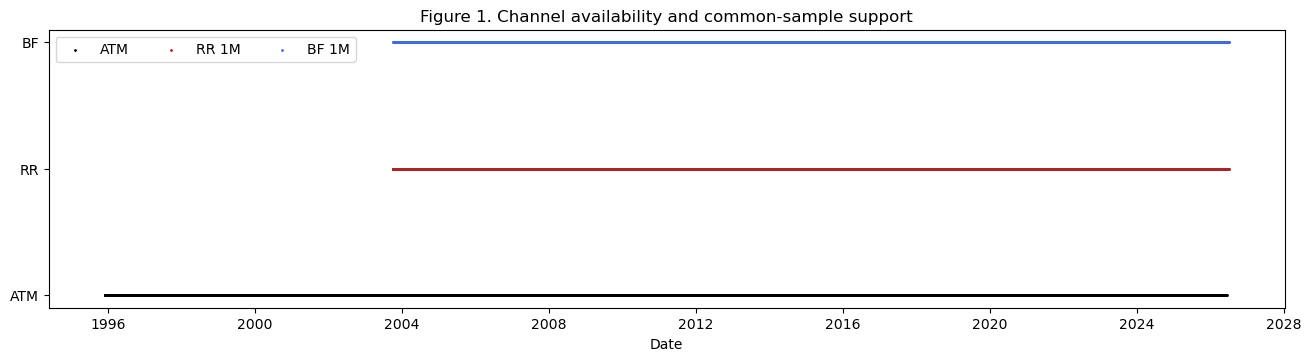

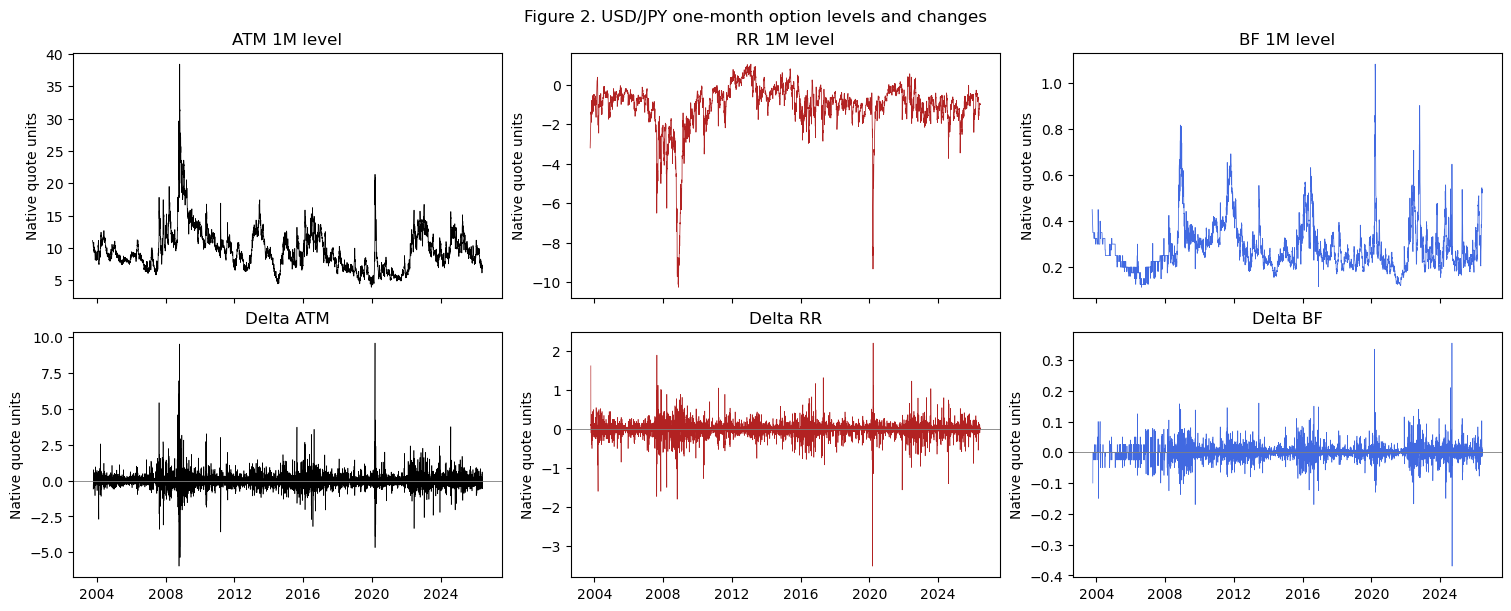

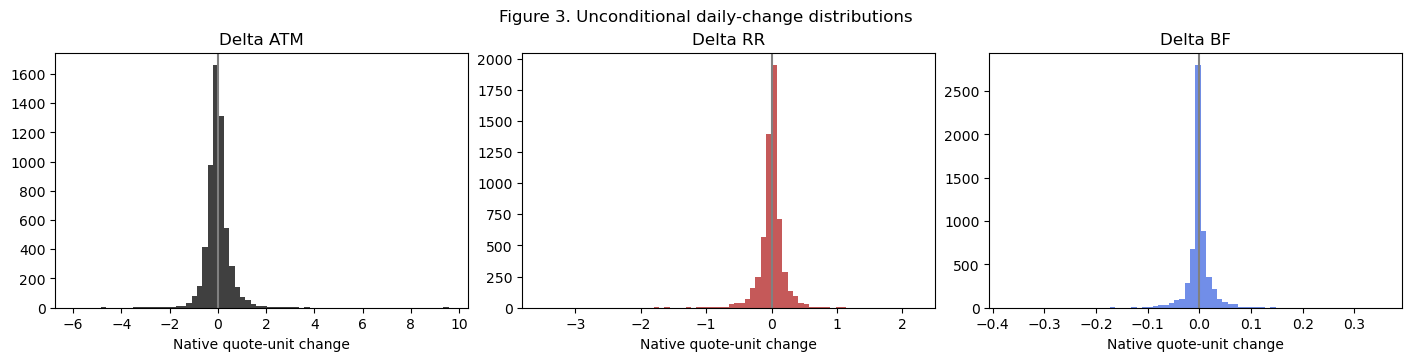

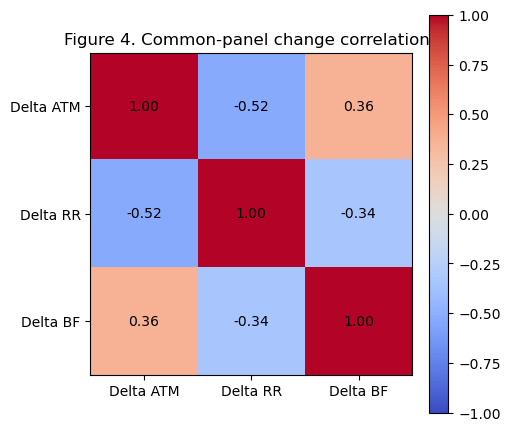

### Native-unit descriptive statistics and correlations

,count,mean,std,min,25%,50%,75%,max
dATM,5877.0,-0.000715,0.576381,-5.9650,-0.2425,-0.025,0.1950,9.5775
dRR,5877.0,0.000376,0.198054,-3.5225,-0.0575,0.000,0.0725,2.2100
dBF,5877.0,0.000015,0.024374,-0.3700,-0.0075,0.000,0.0050,0.3550


,dATM,dRR,dBF
dATM,1.000000,-0.523622,0.359936
dRR,-0.523622,1.000000,-0.342171
dBF,0.359936,-0.342171,1.000000


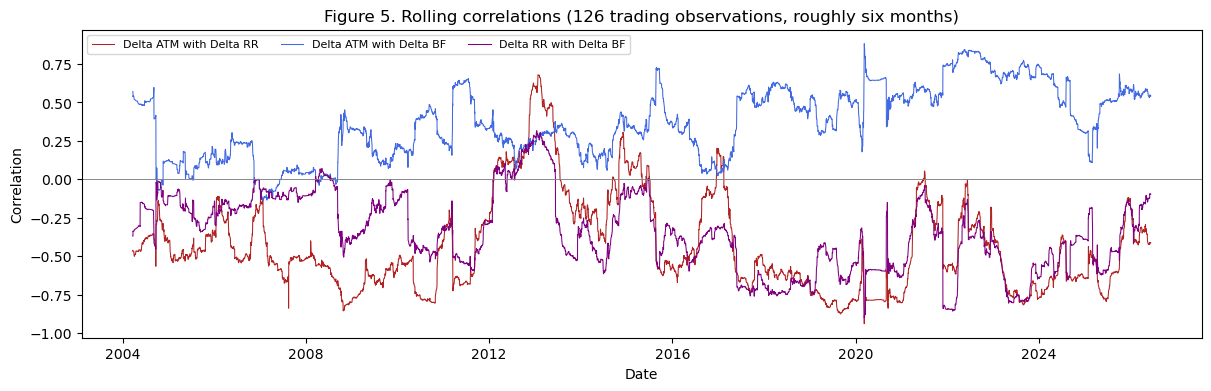

### 126-observation rolling correlation at the final available date

,dATM,dRR,dBF
dATM,1.000000,-0.413764,0.541705
dRR,-0.413764,1.000000,-0.096351
dBF,0.541705,-0.096351,1.000000


In [4]:
change_cols=list(CHANGE.values()); channel_sd=panel[change_cols].iloc[1:].std(ddof=1)
for key,col in CHANGE.items(): panel['z'+key]=panel[col]/channel_sd[col]
descriptive=panel[change_cols].describe().T; corr=panel[change_cols].corr(); rolling=panel[change_cols].rolling(ROLLING_WINDOW,min_periods=90).corr()
fig,ax=plt.subplots(figsize=(13,3.5),constrained_layout=True)
for y,(label,f,color) in enumerate([('ATM',atm_panel,'black'),('RR 1M',rr1,'firebrick'),('BF 1M',bf1,'royalblue')]): ax.scatter(f.date,np.full(len(f),y),s=1,color=color,label=label)
ax.set(yticks=[0,1,2],yticklabels=['ATM','RR','BF'],title='Figure 1. Channel availability and common-sample support',xlabel='Date'); ax.legend(ncol=3); fig.savefig(FIG/'figure_1_multichannel_sample_timeline.png',dpi=160,bbox_inches='tight'); display(fig); plt.close(fig)
fig,axes=plt.subplots(2,3,figsize=(15,6),sharex=True,constrained_layout=True)
for j,(key,col) in enumerate(CHANNELS.items()):
 color=['black','firebrick','royalblue'][j]; axes[0,j].plot(panel.date,panel[col],lw=.55,color=color); axes[0,j].set(title=key+' 1M level',ylabel='Native quote units'); axes[1,j].plot(panel.date,panel[CHANGE[key]],lw=.45,color=color); axes[1,j].axhline(0,color='grey',lw=.6); axes[1,j].set(title='Delta '+key,ylabel='Native quote units')
fig.suptitle('Figure 2. USD/JPY one-month option levels and changes'); fig.savefig(FIG/'figure_2_levels_and_changes.png',dpi=160,bbox_inches='tight'); display(fig); plt.close(fig)
fig,axes=plt.subplots(1,3,figsize=(14,3.5),constrained_layout=True)
for ax,(key,col),color in zip(axes,CHANGE.items(),['black','firebrick','royalblue']): ax.hist(panel[col].dropna(),bins=70,color=color,alpha=.75); ax.axvline(0,color='grey'); ax.set(title='Delta '+key,xlabel='Native quote-unit change')
fig.suptitle('Figure 3. Unconditional daily-change distributions'); fig.savefig(FIG/'figure_3_change_distributions.png',dpi=160,bbox_inches='tight'); display(fig); plt.close(fig)
fig,ax=plt.subplots(figsize=(5,4.2),constrained_layout=True); im=ax.imshow(corr,vmin=-1,vmax=1,cmap='coolwarm'); ax.set(xticks=range(3),yticks=range(3),xticklabels=['Delta ATM','Delta RR','Delta BF'],yticklabels=['Delta ATM','Delta RR','Delta BF'],title='Figure 4. Common-panel change correlations')
for i in range(3):
 for j in range(3): ax.text(j,i,f'{corr.iloc[i,j]:.2f}',ha='center',va='center')
fig.colorbar(im,ax=ax); fig.savefig(FIG/'figure_4_change_correlation_matrix.png',dpi=160,bbox_inches='tight'); display(fig); plt.close(fig)
display(Markdown('### Native-unit descriptive statistics and correlations')); display(descriptive); display(corr); fig,ax=plt.subplots(figsize=(12,3.8),constrained_layout=True)
for a,b,color,label in [('dATM','dRR','firebrick','Delta ATM with Delta RR'),('dATM','dBF','royalblue','Delta ATM with Delta BF'),('dRR','dBF','purple','Delta RR with Delta BF')]:
 ax.plot(panel.date,rolling.loc[(slice(None),a),b].to_numpy(),lw=.75,color=color,label=label)
ax.axhline(0,color='grey',lw=.65); ax.set(title='Figure 5. Rolling correlations (126 trading observations, roughly six months)',xlabel='Date',ylabel='Correlation'); ax.legend(ncol=3,fontsize=8)
fig.savefig(FIG/'figure_5_rolling_correlations.png',dpi=160,bbox_inches='tight'); display(fig); plt.close(fig)
display(Markdown('### 126-observation rolling correlation at the final available date')); display(rolling.xs(panel.index[-1],level=0))


## 6. BoJ and FOMC event studies

For each bank and alignment, complete -20 to +10 event windows are averaged. Bootstrap confidence intervals resample events, not observations. The fixed estimands are pre-event (-5 to -1), immediate (0), short post-event (0 to +2), medium post-event (0 to +5), and selected post-event (0 to +10).

In [5]:
def bh(frame,pcol,qcol,groups):
 frame=frame.copy(); frame[qcol]=np.nan
 for _,idx in frame.groupby(groups).groups.items():
  ids=list(idx); p=frame.loc[ids,pcol].dropna().sort_values(); m=len(p)
  if m: frame.loc[p.index,qcol]=np.minimum(1.0,np.minimum.accumulate((p*m/np.arange(1,m+1))[::-1])[::-1])
 return frame
def event_values(ev,series,offsets):
 a=series.to_numpy(float); return np.vstack([a[int(x)+np.asarray(offsets)] for x in ev.event_index.astype(int)])
def ci(values):
 n=len(values); d=values[rng.integers(0,n,size=(BOOTSTRAPS,n))].mean(axis=1); return float(np.quantile(d,.025)),float(np.quantile(d,.975))
rows=[]
for alignment in ALIGNMENTS:
 for bank in ['BoJ','FOMC']:
  samples=['all_complete','common_period','post_window_clean']+(['strict_full_window_clean'] if bank=='BoJ' else [])
  for sample in samples:
   ev=selected_events(alignment,bank,sample); assert len(ev)>0
   for key,col in CHANGE.items():
    path=event_values(ev,panel[col],EVENT_TIMES)
    for t,v in zip(EVENT_TIMES,path.T):
     lo,hi=ci(v); rows.append({'record_type':'profile','alignment':alignment,'bank':bank,'sample':sample,'channel':key,'event_time':t,'estimand':'time_%+d'%t,'native_estimate':float(v.mean()),'native_lower':lo,'native_upper':hi,'standardised_estimate':float(v.mean()/channel_sd[col]),'standardised_lower':float(lo/channel_sd[col]),'standardised_upper':float(hi/channel_sd[col]),'event_count':len(ev)})
    for name,offsets in ESTIMANDS.items():
     v=event_values(ev,panel[col],offsets).sum(axis=1); lo,hi=ci(v); rows.append({'record_type':'estimand','alignment':alignment,'bank':bank,'sample':sample,'channel':key,'event_time':np.nan,'estimand':name,'native_estimate':float(v.mean()),'native_lower':lo,'native_upper':hi,'standardised_estimate':float(v.mean()/channel_sd[col]),'standardised_lower':float(lo/channel_sd[col]),'standardised_upper':float(hi/channel_sd[col]),'event_count':len(ev)})
event_study_summary=pd.DataFrame(rows); assert event_study_summary.event_count.gt(0).all(); display(Markdown('### Pre-specified event estimands')); display(event_study_summary.query("record_type=='estimand' and sample=='all_complete'"))

### Pre-specified event estimands

,record_type,alignment,bank,sample,channel,event_time,estimand,native_estimate,native_lower,native_upper,standardised_estimate,standardised_lower,standardised_upper,event_count
31,estimand,same_date,BoJ,all_complete,ATM,NaN,pre_5_to_1,-0.054464,-0.243097,0.167313,-0.094493,-0.421764,0.290281,98
32,estimand,same_date,BoJ,all_complete,ATM,NaN,immediate_0,-0.275842,-0.459899,-0.087332,-0.478575,-0.797908,-0.151517,98
33,estimand,same_date,BoJ,all_complete,ATM,NaN,short_0_to_2,-0.200587,-0.381934,-0.010952,-0.348010,-0.662641,-0.019000,98
34,estimand,same_date,BoJ,all_complete,ATM,NaN,medium_0_to_5,-0.340408,-0.572135,-0.111522,-0.590595,-0.992633,-0.193486,98
35,estimand,same_date,BoJ,all_complete,ATM,NaN,selected_0_to_10,-0.119031,-0.410781,0.164527,-0.206514,-0.712689,0.285448,98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1327,estimand,next_observation,FOMC,all_complete,BF,NaN,immediate_0,0.002500,-0.004750,0.009744,0.102569,-0.194881,0.399756,39
1328,estimand,next_observation,FOMC,all_complete,BF,NaN,short_0_to_2,0.001346,-0.018760,0.023144,0.055229,-0.769662,0.949552,39
1329,estimand,next_observation,FOMC,all_complete,BF,NaN,medium_0_to_5,0.006603,-0.016673,0.028849,0.270887,-0.684056,1.183620,39
1330,estimand,next_observation,FOMC,all_complete,BF,NaN,selected_0_to_10,-0.002564,-0.027891,0.022439,-0.105199,-1.144302,0.920622,39


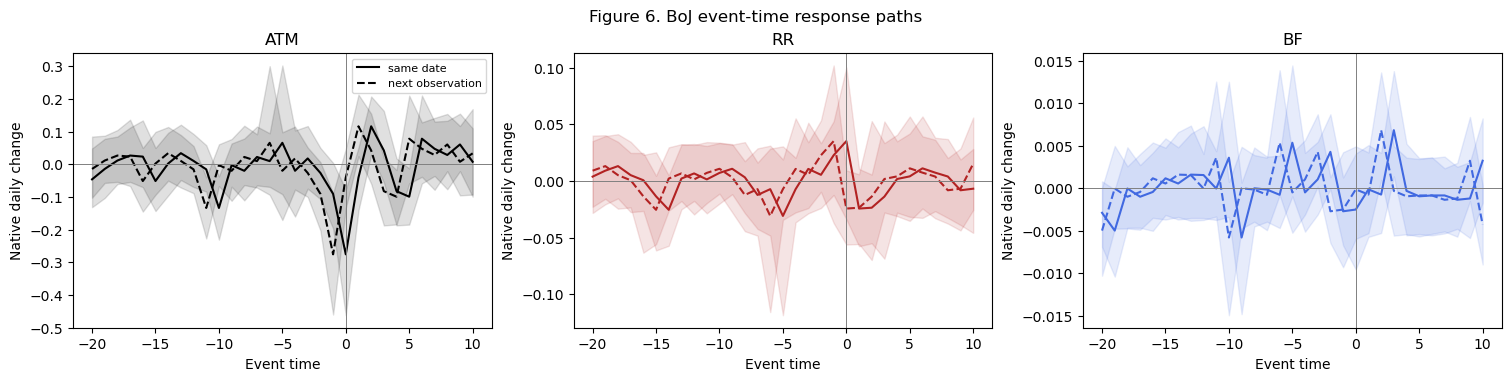

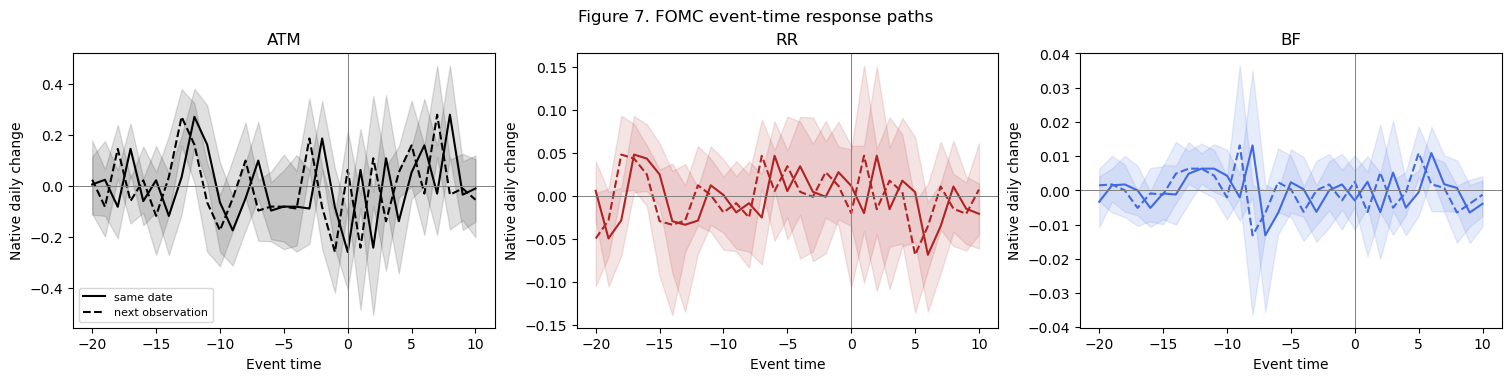

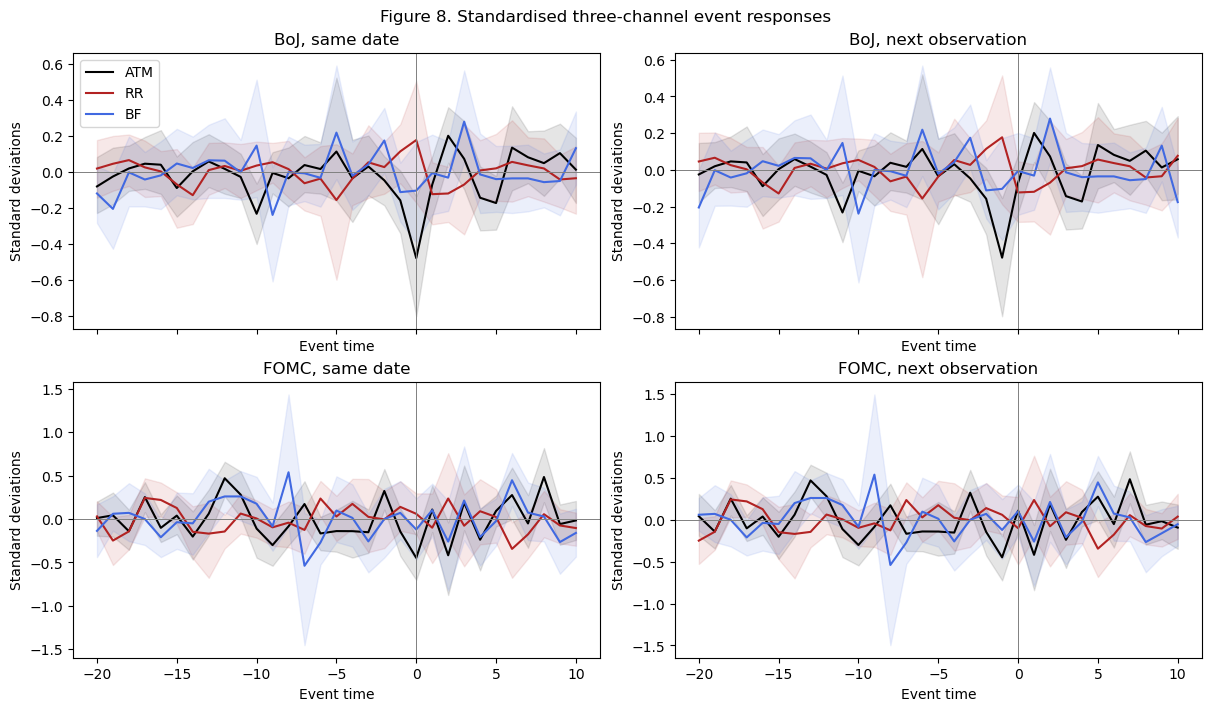

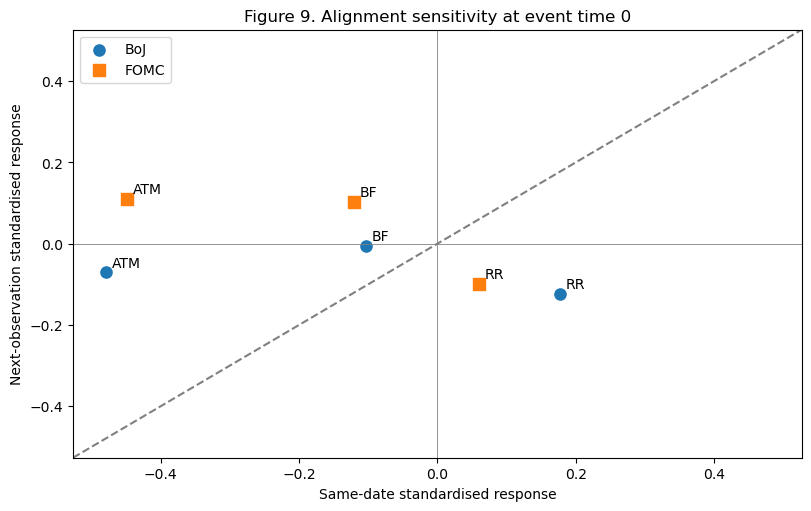

In [6]:
def profile_frame(alignment,bank,key): return event_study_summary.query("record_type=='profile' and alignment==@alignment and bank==@bank and sample=='all_complete' and channel==@key").sort_values('event_time')
for bank,num in [('BoJ',6),('FOMC',7)]:
 fig,axes=plt.subplots(1,3,figsize=(15,3.7),sharex=True,constrained_layout=True)
 for ax,(key,col),color in zip(axes,CHANNELS.items(),['black','firebrick','royalblue']):
  for alignment,ls in [('same_date','-'),('next_observation','--')]:
   q=profile_frame(alignment,bank,key); ax.plot(q.event_time,q.native_estimate,color=color,ls=ls,label=alignment.replace('_',' ')); ax.fill_between(q.event_time,q.native_lower,q.native_upper,color=color,alpha=.12)
  ax.axhline(0,color='grey',lw=.7); ax.axvline(0,color='grey',lw=.7); ax.set(title=key,xlabel='Event time',ylabel='Native daily change')
 axes[0].legend(fontsize=8); fig.suptitle(f'Figure {num}. {bank} event-time response paths'); fig.savefig(FIG/f'figure_{num}_{bank.lower()}_event_time_paths.png',dpi=160,bbox_inches='tight'); display(fig); plt.close(fig)
fig,axes=plt.subplots(2,2,figsize=(12,7),sharex=True,constrained_layout=True)
for ax,(bank,alignment) in zip(axes.ravel(),[(b,a) for b in ['BoJ','FOMC'] for a in ALIGNMENTS]):
 for key,color in zip(CHANNELS,['black','firebrick','royalblue']):
  q=profile_frame(alignment,bank,key); ax.plot(q.event_time,q.standardised_estimate,color=color,label=key); ax.fill_between(q.event_time,q.standardised_lower,q.standardised_upper,color=color,alpha=.10)
 ax.axhline(0,color='grey',lw=.7); ax.axvline(0,color='grey',lw=.7); ax.set(title=bank+', '+alignment.replace('_',' '),xlabel='Event time',ylabel='Standard deviations')
axes[0,0].legend(); fig.suptitle('Figure 8. Standardised three-channel event responses'); fig.savefig(FIG/'figure_8_combined_standardised_responses.png',dpi=160,bbox_inches='tight'); display(fig); plt.close(fig)
q=event_study_summary.query("record_type=='estimand' and estimand=='immediate_0' and sample=='all_complete'").pivot(index=['bank','channel'],columns='alignment',values='standardised_estimate').reset_index()
fig,ax=plt.subplots(figsize=(8,5),constrained_layout=True)
for bank,marker in [('BoJ','o'),('FOMC','s')]:
 z=q.loc[q.bank.eq(bank)]; ax.scatter(z.same_date,z.next_observation,label=bank,marker=marker,s=65)
 for r in z.itertuples(): ax.annotate(r.channel,(r.same_date,r.next_observation),xytext=(4,4),textcoords='offset points')
lim=max(.1,float(np.abs(q[['same_date','next_observation']].to_numpy()).max())*1.1); ax.plot([-lim,lim],[-lim,lim],color='grey',ls='--'); ax.axhline(0,color='grey',lw=.6); ax.axvline(0,color='grey',lw=.6); ax.set(xlim=(-lim,lim),ylim=(-lim,lim),xlabel='Same-date standardised response',ylabel='Next-observation standardised response',title='Figure 9. Alignment sensitivity at event time 0'); ax.legend(); fig.savefig(FIG/'figure_9_alignment_sensitivity.png',dpi=160,bbox_inches='tight'); display(fig); plt.close(fig)


## 7. Matched pseudo-event analysis

Pseudo-events are sampled within the actual event's calendar year and weekday from complete windows outside every real-event window. This preserves event count and calendar composition as far as the common panel permits. Empirical two-sided placebo p-values are BH-corrected within each alignment, sample, and estimand across the six bank-channel tests.

In [7]:
# Matched pseudo-event centres retain contiguous windows and disclose any matching fallback.
match_rng=np.random.default_rng(SEEDS['matched_windows']); placebo_rng=np.random.default_rng(SEEDS['placebo']); candidate_cache={}; matched_plan_cache={}
def candidate_positions(alignment,row):
 key=(alignment,row.event_id)
 if key in candidate_cache: return candidate_cache[key]
 genuine=aligned[alignment].query('not outside_panel').event_index.astype(int).to_numpy(); allpos=np.arange(20,len(panel)-10)
 clean=allpos[~np.array([np.any((genuine>=x-20)&(genuine<=x+10)) for x in allpos])]
 year=panel.date.iloc[int(row.event_index)].year; dow=panel.date.iloc[int(row.event_index)].dayofweek
 ordered=[('exact year and weekday match',clean[(panel.date.iloc[clean].dt.year.to_numpy()==year)&(panel.date.iloc[clean].dt.dayofweek.to_numpy()==dow)]),('year-only fallback',clean[panel.date.iloc[clean].dt.year.to_numpy()==year]),('weekday-only fallback',clean[panel.date.iloc[clean].dt.dayofweek.to_numpy()==dow]),('unrestricted fallback',clean)]
 for label,x in ordered:
  if len(x): candidate_cache[key]=(np.asarray(x,dtype=int),label); return candidate_cache[key]
 candidate_cache[key]=(np.array([],dtype=int),'no eligible match'); return candidate_cache[key]
def matched_plan(alignment,bank,sample):
 key=(alignment,bank,sample)
 if key in matched_plan_cache: return matched_plan_cache[key]
 records=[]
 for row in selected_events(alignment,bank,sample).itertuples(index=False):
  options,quality=candidate_positions(alignment,row); assert len(options)>0, f'No pseudo-event candidate for {row.event_id}'
  records.append({'event_id':row.event_id,'bank':bank,'sample':sample,'alignment':alignment,'actual_index':int(row.event_index),'pseudo_index':int(options[match_rng.integers(len(options))]),'matching_category':quality})
 out=pd.DataFrame(records); matched_plan_cache[key]=out; return out
def pseudo_values(plan,series,offsets):
 a=series.to_numpy(float); pos=plan.pseudo_index.to_numpy(int); return a[pos[:,None]+np.asarray(offsets)].sum(axis=1)
def placebo(ev,series,offsets,alignment,bank,sample):
 actual=float(event_values(ev,series,offsets).sum(axis=1).mean()); pools=[candidate_positions(alignment,r)[0] for r in ev.itertuples(index=False)]; assert all(len(x) for x in pools)
 a=series.to_numpy(float); positions=np.column_stack([x[placebo_rng.integers(len(x),size=PLACEBO_DRAWS)] for x in pools]); draws=a[positions[:,:,None]+np.asarray(offsets)].sum(axis=2).mean(axis=1)
 centre=float(draws.mean()); p=(1+(np.abs(draws-centre)>=abs(actual-centre)).sum())/(len(draws)+1); return actual,centre,float(np.quantile(draws,.025)),float(np.quantile(draws,.975)),float(p)
rows=[]; quality=[]
for alignment in ALIGNMENTS:
 for bank in ['BoJ','FOMC']:
  for sample in ['all_complete','common_period','post_window_clean']+(['strict_full_window_clean'] if bank=='BoJ' else []):
   plan=matched_plan(alignment,bank,sample)
   for category in ['exact year and weekday match','year-only fallback','weekday-only fallback','unrestricted fallback','no eligible match']:
    quality.append({'alignment':alignment,'bank':bank,'sample':sample,'matching_category':category,'event_count':int(plan.matching_category.eq(category).sum()),'share_of_events':float(plan.matching_category.eq(category).mean())})
  for sample in ['all_complete','common_period']:
   ev=selected_events(alignment,bank,sample)
   for key,col in CHANGE.items():
    for estimand,offsets in ESTIMANDS.items():
     actual,mean,lo,hi,pv=placebo(ev,panel[col],offsets,alignment,bank,sample); rows.append({'alignment':alignment,'bank':bank,'sample':sample,'channel':key,'estimand':estimand,'event_count':len(ev),'actual_native_estimate':actual,'placebo_mean':mean,'actual_minus_placebo':actual-mean,'placebo_lower':lo,'placebo_upper':hi,'empirical_p_value':pv})
placebo_matching_quality=pd.DataFrame(quality); placebo_results=bh(pd.DataFrame(rows),'empirical_p_value','bh_q_value',['alignment','sample','estimand']); placebo_results['bh_significant_5pct']=placebo_results.bh_q_value.le(ALPHA); assert placebo_results.groupby(['alignment','sample','estimand']).size().eq(6).all(); assert placebo_matching_quality.query("matching_category=='no eligible match'").event_count.sum()==0
display(Markdown('### Matched pseudo-event quality')); display(placebo_matching_quality); display(Markdown('### Placebo results')); display(placebo_results.query("sample=='all_complete'"))


### Matched pseudo-event quality

,alignment,bank,sample,matching_category,event_count,share_of_events
0,same_date,BoJ,all_complete,exact year and weekday match,91,0.928571
1,same_date,BoJ,all_complete,year-only fallback,7,0.071429
2,same_date,BoJ,all_complete,weekday-only fallback,0,0.000000
3,same_date,BoJ,all_complete,unrestricted fallback,0,0.000000
4,same_date,BoJ,all_complete,no eligible match,0,0.000000
...,...,...,...,...,...,...
65,next_observation,FOMC,post_window_clean,exact year and weekday match,11,0.578947
66,next_observation,FOMC,post_window_clean,year-only fallback,8,0.421053
67,next_observation,FOMC,post_window_clean,weekday-only fallback,0,0.000000
68,next_observation,FOMC,post_window_clean,unrestricted fallback,0,0.000000


### Placebo results

,alignment,bank,sample,channel,estimand,event_count,actual_native_estimate,placebo_mean,actual_minus_placebo,placebo_lower,placebo_upper,empirical_p_value,bh_q_value,bh_significant_5pct
0,same_date,BoJ,all_complete,ATM,pre_5_to_1,98,-0.054464,0.158025,-0.212490,0.061286,0.254540,0.001,0.0015,True
1,same_date,BoJ,all_complete,ATM,immediate_0,98,-0.275842,-0.000899,-0.274943,-0.049570,0.052020,0.001,0.0015,True
2,same_date,BoJ,all_complete,ATM,short_0_to_2,98,-0.200587,0.095512,-0.296099,0.005093,0.181602,0.001,0.0012,True
3,same_date,BoJ,all_complete,ATM,medium_0_to_5,98,-0.340408,0.054945,-0.395353,-0.067589,0.175621,0.001,0.0012,True
4,same_date,BoJ,all_complete,ATM,selected_0_to_10,98,-0.119031,0.399206,-0.518237,0.112987,0.752754,0.003,0.0030,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,next_observation,FOMC,all_complete,BF,immediate_0,39,0.002500,0.005867,-0.003367,0.003330,0.008337,0.008,0.0160,True
122,next_observation,FOMC,all_complete,BF,short_0_to_2,39,0.001346,0.018273,-0.016927,0.007756,0.037506,0.031,0.0495,True
123,next_observation,FOMC,all_complete,BF,medium_0_to_5,39,0.006603,0.041969,-0.035367,0.026151,0.062833,0.003,0.0060,True
124,next_observation,FOMC,all_complete,BF,selected_0_to_10,39,-0.002564,0.029138,-0.031702,0.022753,0.035513,0.001,0.0030,True


## 8. Joint multichannel response tests

The joint statistic is a Hotelling-type quadratic mean-response statistic, computed from the event-date mean residual vector and its sample covariance. The matched schedule-permutation p-value is the primary inferential result. The chi-squared p-value is retained only as an asymptotic reference; it is not labelled a HAC joint Wald test. Channel-specific regressions retain HAC inference for their own coefficients.


In [8]:
def event_indicator(ev):
 x=np.zeros(len(panel)); x[ev.event_index.astype(int).to_numpy()]=1; return x
def other_indicator(alignment,bank): return event_indicator(aligned[alignment].query('bank!=@bank and complete_window and not outside_panel'))
def base_frame(y,p,other):
 d=pd.DataFrame({'y':y,'spot':panel.spot_log_return.to_numpy(float),'other':other,**{'dow_'+str(j):panel['dow_'+str(j)] for j in range(1,5)}})
 for lag in range(1,p+1): d['y_lag'+str(lag)]=pd.Series(y).shift(lag); d['spot_lag'+str(lag)]=pd.Series(panel.spot_log_return).shift(lag)
 return d.dropna()
def residual_models(alignment,bank,ev):
 other=other_indicator(alignment,bank); out={}; details=[]; target=event_indicator(ev)
 for key,col in CHANGE.items():
  y=panel[col].to_numpy(float); fits=[]
  for p in range(1,4):
   d=base_frame(y,p,other); fits.append((sm.OLS(d.y,sm.add_constant(d.drop(columns='y'))).fit().bic,p,d))
  _,p,d=min(fits,key=lambda z:z[0]); base=sm.OLS(d.y,sm.add_constant(d.drop(columns='y'))).fit(); full=d.copy(); full['target']=target[d.index]; eventfit=sm.OLS(full.y,sm.add_constant(full.drop(columns='y'))).fit(cov_type='HAC',cov_kwds={'maxlags':10}); out[key]=pd.Series(base.resid,index=d.index); details.append({'channel':key,'selected_ar_order':p,'event_coefficient':float(eventfit.params.target),'hac_standard_error':float(eventfit.bse.target),'hac_p_value':float(eventfit.pvalues.target),'observation_count':len(d)})
 return out,pd.DataFrame(details)
def joint_response_stat(m):
 n=len(m); mean=np.asarray(m).mean(0); cov=np.cov(np.asarray(m),rowvar=False); value=float(n*mean@np.linalg.pinv(cov)@mean); return value,float(stats.chi2.sf(value,3))
joint_rng=np.random.default_rng(SEEDS['joint']); rows=[]
for alignment in ALIGNMENTS:
 for bank in ['BoJ','FOMC']:
  samples=['all_complete','common_period','post_window_clean']+(['strict_full_window_clean'] if bank=='BoJ' else [])
  for sample in samples:
   ev=selected_events(alignment,bank,sample); residuals,detail=residual_models(alignment,bank,ev); ix=ev.event_index.astype(int).to_numpy(); m=np.column_stack([residuals[k].reindex(ix).to_numpy() for k in CHANNELS]); assert np.isfinite(m).all(); stat0,p0=joint_response_stat(m); pools=[candidate_positions(alignment,r)[0] for r in ev.itertuples(index=False)]; perms=[]
   for _ in range(JOINT_PERMUTATIONS):
    pos=np.array([x[joint_rng.integers(len(x))] for x in pools]); perms.append(joint_response_stat(np.column_stack([residuals[k].reindex(pos).to_numpy() for k in CHANNELS]))[0])
   row={'alignment':alignment,'bank':bank,'sample':sample,'event_count':len(ev),'joint_response_statistic':stat0,'asymptotic_chi2_reference_p_value':p0,'joint_schedule_permutation_p_value':float((1+(np.asarray(perms)>=stat0).sum())/(JOINT_PERMUTATIONS+1)),'joint_statistic_label':'Hotelling-type mean-response statistic; asymptotic reference only'}
   for d in detail.itertuples(index=False): row[d.channel+'_coefficient']=d.event_coefficient; row[d.channel+'_hac_p_value']=d.hac_p_value; row[d.channel+'_ar_order']=d.selected_ar_order
   rows.append(row)
joint_response_tests=bh(pd.DataFrame(rows),'joint_schedule_permutation_p_value','joint_schedule_permutation_q_value',['alignment','sample']); joint_response_tests['joint_permutation_supported_5pct']=joint_response_tests.joint_schedule_permutation_q_value.le(ALPHA); display(Markdown('### Joint response tests (permutation inference is primary)')); display(joint_response_tests)


### Joint response tests (permutation inference is primary)

,alignment,bank,sample,event_count,joint_response_statistic,asymptotic_chi2_reference_p_value,joint_schedule_permutation_p_value,joint_statistic_label,ATM_coefficient,ATM_hac_p_value,ATM_ar_order,RR_coefficient,RR_hac_p_value,RR_ar_order,BF_coefficient,BF_hac_p_value,BF_ar_order,joint_schedule_permutation_q_value,joint_permutation_supported_5pct
0,same_date,BoJ,all_complete,98,7.941661,0.047233,0.888,Hotelling-type mean-response statistic; asympt...,-0.251962,0.008427,1,0.042938,0.094984,1,-0.003818,0.249988,1,0.888,False
1,same_date,BoJ,common_period,38,11.269677,0.010354,0.261,Hotelling-type mean-response statistic; asympt...,-0.182359,0.255981,1,0.131309,0.009366,1,-0.003905,0.595254,1,0.522,False
2,same_date,BoJ,post_window_clean,76,8.629363,0.034647,0.608,Hotelling-type mean-response statistic; asympt...,-0.308225,0.003768,1,0.022463,0.422262,1,-0.004034,0.247370,1,0.608,False
3,same_date,BoJ,strict_full_window_clean,46,8.960462,0.029821,0.110,Hotelling-type mean-response statistic; asympt...,-0.256455,0.072534,1,-0.021801,0.432192,1,-0.003846,0.258462,1,0.110,False
4,same_date,FOMC,all_complete,39,14.468712,0.002332,0.647,Hotelling-type mean-response statistic; asympt...,-0.300504,0.000384,1,0.033504,0.130167,1,-0.003275,0.464755,1,0.888,False
5,same_date,FOMC,common_period,39,14.468712,0.002332,0.657,Hotelling-type mean-response statistic; asympt...,-0.300504,0.000384,1,0.033504,0.130167,1,-0.003275,0.464755,1,0.657,False
6,same_date,FOMC,post_window_clean,19,15.707151,0.001302,0.236,Hotelling-type mean-response statistic; asympt...,-0.479465,0.000227,1,0.065722,0.015234,1,-0.008134,0.290946,1,0.472,False
7,next_observation,BoJ,all_complete,98,7.747512,0.051529,0.696,Hotelling-type mean-response statistic; asympt...,-0.099333,0.038340,1,-0.008968,0.551545,1,-0.001700,0.526847,1,1.000,False
8,next_observation,BoJ,common_period,38,3.671067,0.299244,0.947,Hotelling-type mean-response statistic; asympt...,-0.049653,0.486908,1,-0.033091,0.309564,1,-0.004165,0.481747,1,1.000,False
9,next_observation,BoJ,post_window_clean,76,8.969372,0.029701,0.535,Hotelling-type mean-response statistic; asympt...,-0.120987,0.015474,1,-0.006542,0.621986,1,-0.000562,0.804541,1,0.999,False


## 9. Cross-channel dependence and lead-lag analysis

A positive correlation lag means the source at time *t-k* is compared with the target at time *t*: positive lags therefore describe source-preceding-target ordering. Granger-style models remain directional and retain all six ordered channel pairs. For TDMI only, each unordered pair is used once: for pair X-Y, positive lag +k compares X at *t-k* with Y at *t*, whereas negative lag -k indicates Y preceding X. Lag-zero TDMI is contemporaneous nonlinear dependence only, not sequencing.

TDMI uses fixed observed-context quantile bins and a context-preserving block-permutation null. Source blocks are permuted only within each chronological event or matched-pseudo-event window (or within the full sample), preserving context membership and avoiding false adjacency across windows. Each surrogate repeats the full non-zero-lag search. The lag-asymmetry statistic is the positive-lag maximum minus the negative-lag maximum; it is descriptive, not structural causality. Multiple-testing families are method-, alignment-, context-, and window-specific.


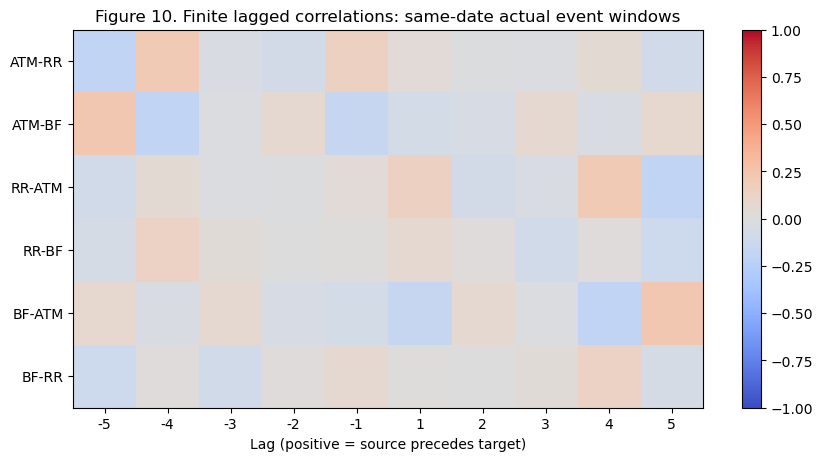

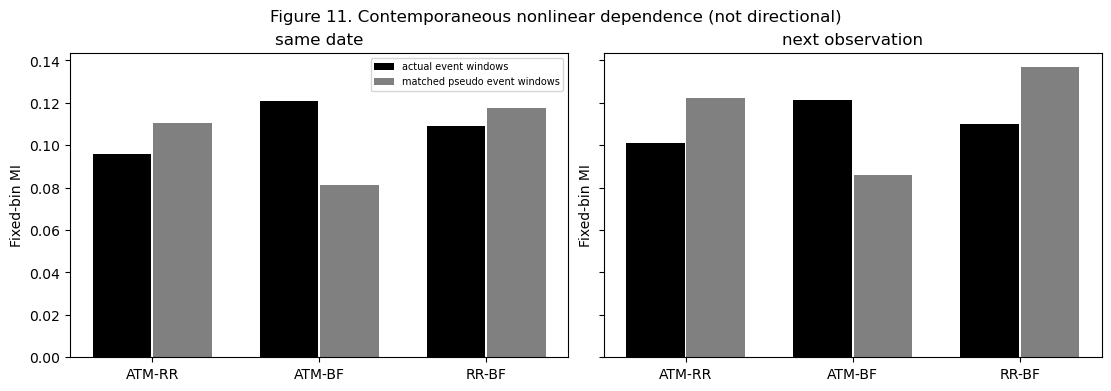

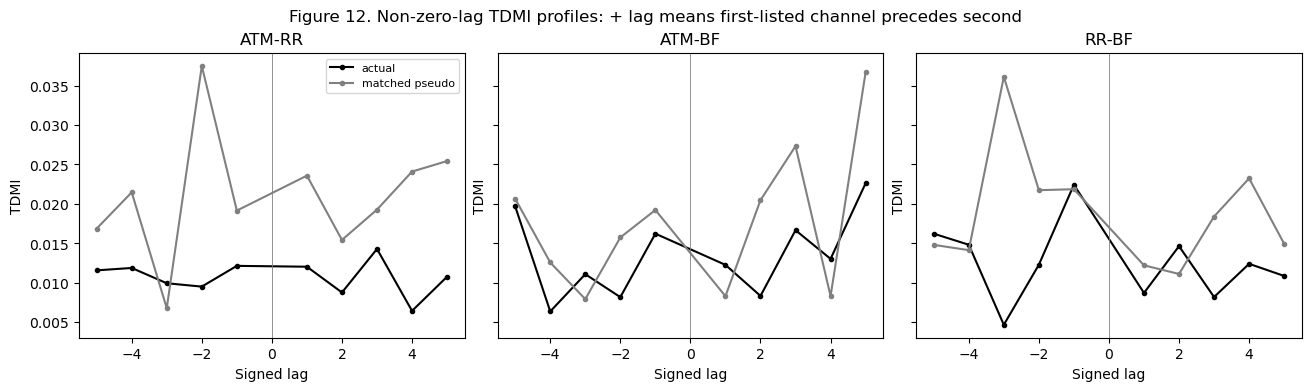

### Main-window signed-lag TDMI summaries

,alignment,context,pair,positive_peak,positive_peak_lag,negative_peak,negative_peak_lag,overall_peak,overall_peak_lag,lag_asymmetry,p_value,bh_q_value,effective_sample_size
135,next_observation,actual_event_windows,ATM-BF,0.021707,5.0,0.017586,-1.0,0.021707,5.0,0.004121,0.970,0.999,1096.0
132,next_observation,actual_event_windows,ATM-RR,0.010630,2.0,0.012747,-4.0,0.012747,-4.0,-0.002117,0.999,0.999,1096.0
138,next_observation,actual_event_windows,RR-BF,0.016853,2.0,0.020915,-1.0,0.020915,-1.0,-0.004062,0.936,0.999,1096.0
156,next_observation,matched_pseudo_event_windows,ATM-BF,0.028362,5.0,0.037865,-5.0,0.037865,-5.0,-0.009503,0.638,0.807,360.0
153,next_observation,matched_pseudo_event_windows,ATM-RR,0.022475,4.0,0.040129,-2.0,0.040129,-2.0,-0.017655,0.558,0.807,360.0
159,next_observation,matched_pseudo_event_windows,RR-BF,0.034358,3.0,0.038531,-4.0,0.038531,-4.0,-0.004172,0.807,0.807,360.0
21,same_date,actual_event_windows,ATM-BF,0.022616,5.0,0.019682,-5.0,0.022616,5.0,0.002934,0.915,0.999,1096.0
18,same_date,actual_event_windows,ATM-RR,0.014293,3.0,0.012154,-1.0,0.014293,3.0,0.002139,0.999,0.999,1096.0
24,same_date,actual_event_windows,RR-BF,0.014653,2.0,0.022429,-1.0,0.022429,-1.0,-0.007776,0.875,0.999,1096.0
42,same_date,matched_pseudo_event_windows,ATM-BF,0.036668,5.0,0.020656,-5.0,0.036668,5.0,0.016012,0.564,0.769,370.0


### Contemporaneous nonlinear dependence

,alignment,context,pair,lag_zero_mi,p_value,bh_q_value,effective_sample_size,source_bins,target_bins
137,next_observation,actual_event_windows,ATM-BF,0.121121,0.001,0.001,1194.0,4.0,4.0
134,next_observation,actual_event_windows,ATM-RR,0.100848,0.001,0.001,1194.0,4.0,4.0
140,next_observation,actual_event_windows,RR-BF,0.110048,0.001,0.001,1194.0,4.0,4.0
158,next_observation,matched_pseudo_event_windows,ATM-BF,0.085829,0.001,0.001,389.0,4.0,4.0
155,next_observation,matched_pseudo_event_windows,ATM-RR,0.122475,0.001,0.001,389.0,4.0,4.0
161,next_observation,matched_pseudo_event_windows,RR-BF,0.136664,0.001,0.001,389.0,4.0,4.0
23,same_date,actual_event_windows,ATM-BF,0.120632,0.001,0.001,1194.0,4.0,4.0
20,same_date,actual_event_windows,ATM-RR,0.096015,0.001,0.001,1194.0,4.0,4.0
26,same_date,actual_event_windows,RR-BF,0.108866,0.001,0.001,1194.0,4.0,4.0
44,same_date,matched_pseudo_event_windows,ATM-BF,0.081063,0.001,0.001,399.0,4.0,4.0


### TDMI robustness summaries

,alignment,context,window,pair,block_length,overall_peak,overall_peak_lag,lag_asymmetry,bh_q_value
136,next_observation,actual_event_windows,main_-5_to_+5,ATM-BF,10.0,0.021707,5.0,0.004121,1.0000
133,next_observation,actual_event_windows,main_-5_to_+5,ATM-RR,10.0,0.012747,-4.0,-0.002117,1.0000
139,next_observation,actual_event_windows,main_-5_to_+5,RR-BF,10.0,0.020915,-1.0,-0.004062,1.0000
212,next_observation,actual_event_windows,robust_-10_to_+5,ATM-BF,5.0,0.014421,-1.0,-0.003090,0.8430
210,next_observation,actual_event_windows,robust_-10_to_+5,ATM-RR,5.0,0.010203,-1.0,-0.000023,0.9610
214,next_observation,actual_event_windows,robust_-10_to_+5,RR-BF,5.0,0.020016,-1.0,-0.005178,0.6240
176,next_observation,actual_event_windows,robust_0_to_+5,ATM-BF,5.0,0.059443,-5.0,-0.023004,0.9790
174,next_observation,actual_event_windows,robust_0_to_+5,ATM-RR,5.0,0.044926,-5.0,-0.014863,0.9790
178,next_observation,actual_event_windows,robust_0_to_+5,RR-BF,5.0,0.041745,-4.0,-0.005172,0.9790
157,next_observation,matched_pseudo_event_windows,main_-5_to_+5,ATM-BF,10.0,0.037865,-5.0,-0.009503,0.7690


In [9]:
PAIRS=[('ATM','RR'),('ATM','BF'),('RR','ATM'),('RR','BF'),('BF','ATM'),('BF','RR')]; UNORDERED=[('ATM','RR'),('ATM','BF'),('RR','BF')]
WINDOWS={'main_-5_to_+5':(-5,5),'robust_0_to_+5':(0,5),'robust_-10_to_+5':(-10,5)}
def lag_pairs(source,target,mask,lag,segment_id=None):
 source=np.asarray(source,dtype=float); target=np.asarray(target,dtype=float); mask=np.asarray(mask,dtype=bool); t=np.arange(len(target)); keep=(t-lag>=0)&(t-lag<len(target)); t=t[keep]; s=t-lag; keep=mask[t]&mask[s]
 if segment_id is not None:
  keep &= (
   (segment_id[t] == segment_id[s])
   & (segment_id[t] >= 0)
  )
 x=source[s[keep]]; y=target[t[keep]]; finite=np.isfinite(x)&np.isfinite(y); return x[finite],y[finite]
# Explicit timing and finite-data tests: +1 maps source[t-1] to target[t], -1 reverses it, with no wraparound.
_x=np.array([10.,20.,np.nan,40.]); _y=np.array([1.,2.,3.,4.]); _m=np.ones(4,bool)
assert np.array_equal(lag_pairs(_x,_y,_m,1)[0],np.array([10.,20.])) and np.array_equal(lag_pairs(_x,_y,_m,1)[1],np.array([2.,3.]))
assert np.array_equal(lag_pairs(_x,_y,_m,-1)[0],np.array([20.,40.])) and np.array_equal(lag_pairs(_x,_y,_m,-1)[1],np.array([1.,3.]))
assert all(z.size==0 for z in lag_pairs(np.array([np.nan]),np.array([1.]),np.array([True]),0))
# A lagged pair may remain inside one segment, but must never cross to the next event-window segment.
_test_source=np.array([10.0,20.0,30.0,40.0]); _test_target=np.array([1.0,2.0,3.0,4.0]); _test_mask=np.ones(4,dtype=bool); _test_segments=np.array([0,0,1,1])
x_test,y_test=lag_pairs(source=_test_source,target=_test_target,mask=_test_mask,lag=1,segment_id=_test_segments)
assert np.array_equal(x_test,np.array([10.0,30.0]))
assert np.array_equal(y_test,np.array([2.0,4.0]))
def fit_quantile_edges(values,requested_bins=TDMI_REQUESTED_BINS):
 v=np.asarray(values,float); v=v[np.isfinite(v)]; edges=np.unique(np.quantile(v,np.linspace(0,1,requested_bins+1))); assert len(edges)>=3, 'TDMI requires at least two usable fixed bins'; return edges,len(edges)-1
def apply_fixed_bins(values,edges):
 values=np.asarray(values,float); return np.where(np.isfinite(values),np.clip(np.searchsorted(edges,values,side='right')-1,0,len(edges)-2),-1).astype(int)
def mi_codes(x,y,nx,ny):
 valid=(x>=0)&(y>=0)
 if valid.sum()<10: return np.nan
 tab=np.bincount(x[valid]*ny+y[valid],minlength=nx*ny).reshape(nx,ny).astype(float); prob=tab/tab.sum(); px=prob.sum(1,keepdims=True); py=prob.sum(0,keepdims=True); positive=prob>0; return float((prob[positive]*np.log(prob[positive]/(px*py)[positive])).sum())
def mi_batch(x,y,nx,ny):
 b=x.shape[0]; valid=(x>=0)&(y[None,:]>=0); out=np.full(b,np.nan)
 if not valid.any(): return out
 ids=np.broadcast_to(np.arange(b)[:,None],x.shape)[valid]*(nx*ny)+x[valid]*ny+np.broadcast_to(y[None,:],x.shape)[valid]; tab=np.bincount(ids,minlength=b*nx*ny).reshape(b,nx,ny).astype(float); total=tab.sum((1,2)); good=total>9; prob=np.divide(tab,total[:,None,None],out=np.zeros_like(tab),where=total[:,None,None]>0); px=prob.sum(2,keepdims=True); py=prob.sum(1,keepdims=True); ratio=np.divide(prob,px*py,out=np.ones_like(prob),where=(px*py)>0); term=np.zeros_like(prob); positive=prob>0; term[positive]=prob[positive]*np.log(ratio[positive]); out[good]=term[good].sum((1,2)); return out
def merged_segments(centres,lo,hi):
 ranges=[]
 for centre in np.asarray(centres,dtype=int): ranges.append((max(0,centre+lo),min(len(panel)-1,centre+hi)))
 ranges.sort(); merged=[]
 for start,end in ranges:
  if not merged or start>merged[-1][1]+1: merged.append([start,end])
  else: merged[-1][1]=max(merged[-1][1],end)
 segid=np.full(len(panel),-1,dtype=int); segments=[]
 for i,(start,end) in enumerate(merged):
  ix=np.arange(start,end+1); segid[ix]=i; segments.append(ix)
 return segid>=0,segid,segments
def context_spec(alignment,window,kind):
 lo,hi=WINDOWS[window]; centres=np.concatenate([selected_events(alignment,b,'all_complete').event_index.astype(int).to_numpy() if kind=='actual' else matched_plan(alignment,b,'all_complete').pseudo_index.astype(int).to_numpy() for b in ['BoJ','FOMC']]); mask,segid,segs=merged_segments(centres,lo,hi); key=('actual_' if kind=='actual' else 'pseudo_')+alignment+'_'+({'main_-5_to_+5':'-5_+5','robust_0_to_+5':'0_+5','robust_-10_to_+5':'-10_+5'}[window]); return {'context':'actual_event_windows' if kind=='actual' else 'matched_pseudo_event_windows','alignment':alignment,'window':window,'seed_key':key,'mask':mask,'segment_id':segid,'segments':segs}
def full_spec(): return {'context':'full_sample','alignment':'not_applicable','window':'full_sample','seed_key':'full_sample','mask':np.ones(len(panel),bool),'segment_id':np.zeros(len(panel),dtype=int),'segments':[np.arange(len(panel))]}
def lag_indices(mask,lag,segment_id):
 t=np.arange(len(panel)); valid=(t-lag>=0)&(t-lag<len(panel)); t=t[valid]; s=t-lag; keep=mask[t]&mask[s]&(segment_id[t]==segment_id[s])&(segment_id[t]>=0); return s[keep],t[keep]
def block_permuted_codes(codes,segments,block_length,n_draws,rng):
 out=np.tile(codes,(n_draws,1)); fallbacks=0
 for ix in segments:
  blocks=[ix[j:j+block_length] for j in range(0,len(ix),block_length)]
  if len(blocks)>=2:
   for r in range(n_draws): out[r,ix]=np.concatenate([codes[blocks[j]] for j in rng.permutation(len(blocks))])
  elif len(ix)>=2:
   fallbacks+=1
   for r in range(n_draws): out[r,ix]=codes[rng.permutation(ix)]
 return out,fallbacks
def surrogate_peak_p(source_codes,target_codes,nx,ny,spec,lags,block_length,seed):
 rng=np.random.default_rng(int(seed)); maxima=[]; fallback_windows=0
 indices=[lag_indices(spec['mask'],int(lag),spec['segment_id']) for lag in lags]
 for start in range(0,TDMI_PERMUTATIONS,24):
  b=min(24,TDMI_PERMUTATIONS-start); shuffled,fallbacks=block_permuted_codes(source_codes,spec['segments'],block_length,b,rng); fallback_windows=max(fallback_windows,fallbacks); peak=np.full(b,-np.inf)
  for s,t in indices: peak=np.maximum(peak,mi_batch(shuffled[:,s],target_codes[t],nx,ny))
  maxima.extend(peak.tolist())
 return np.asarray(maxima),fallback_windows
def tdmi_nonzero(source,target,pair,spec,block_length):
 ex,nx=fit_quantile_edges(source[spec['mask']]); ey,ny=fit_quantile_edges(target[spec['mask']]); xs=apply_fixed_bins(source,ex); yt=apply_fixed_bins(target,ey); values=[]; sizes=[]
 for lag in NONZERO_LAGS:
  s,t=lag_indices(spec['mask'],int(lag),spec['segment_id']); values.append(mi_codes(xs[s],yt[t],nx,ny)); sizes.append(int(((xs[s]>=0)&(yt[t]>=0)).sum()))
 values=np.asarray(values); observed=float(np.nanmax(values)); seed=SEEDS['tdmi']+PAIR_SEED_OFFSETS[pair]+CONTEXT_SEED_OFFSETS[spec['seed_key']]+block_length*10000; null,fallbacks=surrogate_peak_p(xs,yt,nx,ny,spec,NONZERO_LAGS,block_length,seed); p=float((1+(null>=observed).sum())/(TDMI_PERMUTATIONS+1)); pos=values[NONZERO_LAGS>0]; neg=values[NONZERO_LAGS<0]; return {'lag_zero_mi':np.nan,'positive_peak':float(np.nanmax(pos)),'positive_peak_lag':int(NONZERO_LAGS[NONZERO_LAGS>0][np.nanargmax(pos)]),'negative_peak':float(np.nanmax(neg)),'negative_peak_lag':int(NONZERO_LAGS[NONZERO_LAGS<0][np.nanargmax(neg)]),'overall_peak':observed,'overall_peak_lag':int(NONZERO_LAGS[np.nanargmax(values)]),'lag_asymmetry':float(np.nanmax(pos)-np.nanmax(neg)),'p_value':p,'source_bins':nx,'target_bins':ny,'effective_sample_size':int(max(sizes)),'lag_values':json.dumps([float(v) for v in values]),'lag_sample_sizes':json.dumps(sizes),'fallback_windows':fallbacks,'seed':int(seed)}
def tdmi_contemporaneous(source,target,pair,spec,block_length=TDMI_MAIN_BLOCK_LENGTH):
 ex,nx=fit_quantile_edges(source[spec['mask']]); ey,ny=fit_quantile_edges(target[spec['mask']]); xs=apply_fixed_bins(source,ex); yt=apply_fixed_bins(target,ey); observed=mi_codes(xs[spec['mask']],yt[spec['mask']],nx,ny); seed=SEEDS['tdmi']+PAIR_SEED_OFFSETS[pair]+CONTEXT_SEED_OFFSETS[spec['seed_key']]+block_length*10000+1; null,fallbacks=surrogate_peak_p(xs,yt,nx,ny,spec,np.array([0]),block_length,seed); p=float((1+(null>=observed).sum())/(TDMI_PERMUTATIONS+1)); return {'lag_zero_mi':float(observed),'p_value':p,'source_bins':nx,'target_bins':ny,'effective_sample_size':int(((xs[spec['mask']]>=0)&(yt[spec['mask']]>=0)).sum()),'fallback_windows':fallbacks,'seed':int(seed)}
def interaction_granger(source,target,third,mask):
 candidates=[]
 for p in range(1,4):
  d=pd.DataFrame({'y':target,'spot':panel.spot_log_return.to_numpy(float),'D':mask.astype(int),**{'dow_'+str(j):panel['dow_'+str(j)] for j in range(1,5)}})
  for lag in range(1,p+1): d['y'+str(lag)]=pd.Series(target).shift(lag); d['source'+str(lag)]=pd.Series(source).shift(lag); d['third'+str(lag)]=pd.Series(third).shift(lag); d['spot'+str(lag)]=d.spot.shift(lag)
  d=d.dropna(); base=['D']+['dow_'+str(j) for j in range(1,5)]+[z+str(j) for z in ['y','source','third','spot'] for j in range(1,p+1)]; candidates.append((sm.OLS(d.y,sm.add_constant(d[base])).fit().bic,p,d,base))
 _,p,d,base=min(candidates,key=lambda x:x[0]); inter=[]
 for j in range(1,p+1): d['D_source'+str(j)]=d.D*d['source'+str(j)]; inter.append('D_source'+str(j))
 full=sm.OLS(d.y,sm.add_constant(d[base+inter])).fit(cov_type='HAC',cov_kwds={'maxlags':10}); restricted=sm.OLS(d.y,sm.add_constant(d[base])).fit(); R=np.zeros((p,len(full.params))); names=list(full.params.index)
 for j in range(p): R[j,names.index(inter[j])]=1
 test=full.wald_test(R,scalar=True); return p,len(d),float(1-full.ssr/restricted.ssr),float(test.statistic),float(test.pvalue)
context_specs=[full_spec()]
for alignment in ALIGNMENTS:
 for window in WINDOWS:
  for kind in ['actual','pseudo']: context_specs.append(context_spec(alignment,window,kind))
rows=[]
for spec in context_specs:
 coverage=float(spec['mask'].mean())
 if spec['context']!='full_sample':
  for source_key,target_key in PAIRS:
   source=panel[CHANGE[source_key]].to_numpy(float); target=panel[CHANGE[target_key]].to_numpy(float); third=panel[CHANGE[next(k for k in CHANNELS if k not in {source_key,target_key})]].to_numpy(float); corrs=[]
   for lag in NONZERO_LAGS:
    x,y=lag_pairs(source,target,spec['mask'],int(lag),spec['segment_id']); corrs.append(np.corrcoef(x,y)[0,1] if len(x)>2 else np.nan)
   corrs=np.asarray(corrs); peak=int(np.nanargmax(np.abs(corrs))); rows.append({'alignment':spec['alignment'],'context':spec['context'],'window':spec['window'],'source_channel':source_key,'target_channel':target_key,'pair':source_key+'-'+target_key,'method':'correlation','lag_type':'nonzero_directional','peak_lag':int(NONZERO_LAGS[peak]),'statistic':float(corrs[peak]),'positive_peak':float(np.nanmax(corrs[NONZERO_LAGS>0])),'negative_peak':float(np.nanmax(corrs[NONZERO_LAGS<0])),'observation_count':int(spec['mask'].sum()),'context_coverage':coverage})
   p,n,inc,stat0,pv=interaction_granger(source,target,third,spec['mask']); rows.append({'alignment':spec['alignment'],'context':spec['context'],'window':spec['window'],'source_channel':source_key,'target_channel':target_key,'pair':source_key+'-'+target_key,'method':'granger_interaction','lag_type':'interaction_source_lags','selected_ar_order':p,'statistic':stat0,'p_value':pv,'incremental_r2':inc,'observation_count':n,'context_coverage':coverage,'chronology_preserved':True})
 for pair in UNORDERED:
  source=panel[CHANGE[pair[0]]].to_numpy(float); target=panel[CHANGE[pair[1]]].to_numpy(float); blocks=[TDMI_MAIN_BLOCK_LENGTH] if spec['window']!='main_-5_to_+5' else [TDMI_MAIN_BLOCK_LENGTH,TDMI_ROBUST_BLOCK_LENGTH]
  for block_length in blocks:
   z=tdmi_nonzero(source,target,pair,spec,block_length); rows.append({'alignment':spec['alignment'],'context':spec['context'],'window':spec['window'],'source_channel':pair[0],'target_channel':pair[1],'pair':pair[0]+'-'+pair[1],'method':'tdmi_nonzero_peak','lag_type':'nonzero_signed_unordered','block_length':block_length,'surrogate_draws':TDMI_PERMUTATIONS,'context_coverage':coverage,**z})
  z=tdmi_contemporaneous(source,target,pair,spec); rows.append({'alignment':spec['alignment'],'context':spec['context'],'window':spec['window'],'source_channel':pair[0],'target_channel':pair[1],'pair':pair[0]+'-'+pair[1],'method':'tdmi_contemporaneous','lag_type':'zero_contemporaneous_unordered','block_length':TDMI_MAIN_BLOCK_LENGTH,'surrogate_draws':TDMI_PERMUTATIONS,'context_coverage':coverage,**z})
cross_channel_dependence=pd.DataFrame(rows); cross_channel_dependence['bh_q_value']=np.nan
for method in ['granger_interaction','tdmi_nonzero_peak','tdmi_contemporaneous']:
 sub=bh(cross_channel_dependence.loc[cross_channel_dependence.method.eq(method)],'p_value','bh_q_value',['alignment','context','window','method','block_length'] if method.startswith('tdmi') else ['alignment','context','window','method']); cross_channel_dependence.loc[sub.index,'bh_q_value']=sub.bh_q_value
cross_channel_dependence['bh_supported_5pct']=cross_channel_dependence.bh_q_value.le(ALPHA)
assert set(cross_channel_dependence.query("method.str.startswith('tdmi')",engine='python').pair.dropna())=={'ATM-RR','ATM-BF','RR-BF'}; assert cross_channel_dependence.query("method=='tdmi_nonzero_peak'").overall_peak_lag.ne(0).all(); assert cross_channel_dependence.query("method=='tdmi_contemporaneous'").groupby(['alignment','context','window','block_length']).size().eq(3).all(); assert cross_channel_dependence.bh_q_value.dropna().between(0,1).all(); assert cross_channel_dependence.query("method.str.startswith('tdmi')",engine='python').p_value.between(0,1).all()
# Figure 10: finite lead-lag correlations. Figure 11: contemporaneous TDMI. Figure 12: signed-lag TDMI profiles.
main=context_spec('same_date','main_-5_to_+5','actual'); fig,ax=plt.subplots(figsize=(9,4.5),constrained_layout=True); data=np.vstack([[np.corrcoef(*lag_pairs(panel[CHANGE[s]],panel[CHANGE[t]],main['mask'],int(lag),main['segment_id']))[0,1] for lag in NONZERO_LAGS] for s,t in PAIRS]); im=ax.imshow(data,vmin=-1,vmax=1,cmap='coolwarm'); ax.set(xticks=range(len(NONZERO_LAGS)),xticklabels=NONZERO_LAGS,yticks=range(len(PAIRS)),yticklabels=[a+'-'+b for a,b in PAIRS],xlabel='Lag (positive = source precedes target)',title='Figure 10. Finite lagged correlations: same-date actual event windows'); fig.colorbar(im,ax=ax); fig.savefig(FIG/'figure_10_finite_lagged_correlation_heatmap.png',dpi=160,bbox_inches='tight'); display(fig); plt.close(fig)
q=cross_channel_dependence.query("method=='tdmi_contemporaneous' and window=='main_-5_to_+5' and block_length==@TDMI_MAIN_BLOCK_LENGTH"); fig,axes=plt.subplots(1,2,figsize=(11,3.8),sharey=True,constrained_layout=True)
for ax,alignment in zip(axes,ALIGNMENTS):
 z=q.loc[q.alignment.eq(alignment)];
 for context,offset,color in [('actual_event_windows',-.18,'black'),('matched_pseudo_event_windows',.18,'grey')]:
  a=z.loc[z.context.eq(context)].set_index('pair').reindex(['ATM-RR','ATM-BF','RR-BF']); ax.bar(np.arange(3)+offset,a.lag_zero_mi,width=.35,color=color,label=context.replace('_',' '))
 ax.set(xticks=range(3),xticklabels=['ATM-RR','ATM-BF','RR-BF'],title=alignment.replace('_',' '),ylabel='Fixed-bin MI')
axes[0].legend(fontsize=7); fig.suptitle('Figure 11. Contemporaneous nonlinear dependence (not directional)'); fig.savefig(FIG/'figure_11_contemporaneous_tdmi.png',dpi=160,bbox_inches='tight'); display(fig); plt.close(fig)
fig,axes=plt.subplots(1,3,figsize=(13,3.8),sharey=True,constrained_layout=True)
for ax,pair in zip(axes,UNORDERED):
 for kind,color in [('actual','black'),('pseudo','grey')]:
  spec=context_spec('same_date','main_-5_to_+5',kind); source=panel[CHANGE[pair[0]]].to_numpy(float); target=panel[CHANGE[pair[1]]].to_numpy(float); ex,nx=fit_quantile_edges(source[spec['mask']]); ey,ny=fit_quantile_edges(target[spec['mask']]); xs=apply_fixed_bins(source,ex); yt=apply_fixed_bins(target,ey); vals=[mi_codes(xs[lag_indices(spec['mask'],int(l),spec['segment_id'])[0]],yt[lag_indices(spec['mask'],int(l),spec['segment_id'])[1]],nx,ny) for l in NONZERO_LAGS]; ax.plot(NONZERO_LAGS,vals,'o-',ms=3,color=color,label='actual' if kind=='actual' else 'matched pseudo')
 ax.axvline(0,color='grey',lw=.6); ax.set(title=pair[0]+'-'+pair[1],xlabel='Signed lag',ylabel='TDMI')
axes[0].legend(fontsize=8); fig.suptitle('Figure 12. Non-zero-lag TDMI profiles: + lag means first-listed channel precedes second'); fig.savefig(FIG/'figure_12_nonzero_lag_tdmi_profiles.png',dpi=160,bbox_inches='tight'); display(fig); plt.close(fig)
primary_tdmi=cross_channel_dependence.query("method=='tdmi_nonzero_peak' and window=='main_-5_to_+5' and block_length==@TDMI_MAIN_BLOCK_LENGTH")[['alignment','context','pair','positive_peak','positive_peak_lag','negative_peak','negative_peak_lag','overall_peak','overall_peak_lag','lag_asymmetry','p_value','bh_q_value','effective_sample_size']].sort_values(['alignment','context','pair'])
primary_zero=cross_channel_dependence.query("method=='tdmi_contemporaneous' and window=='main_-5_to_+5'")[['alignment','context','pair','lag_zero_mi','p_value','bh_q_value','effective_sample_size','source_bins','target_bins']].sort_values(['alignment','context','pair'])
robust_tdmi=cross_channel_dependence.query("method=='tdmi_nonzero_peak' and (window!='main_-5_to_+5' or block_length==@TDMI_ROBUST_BLOCK_LENGTH)")[['alignment','context','window','pair','block_length','overall_peak','overall_peak_lag','lag_asymmetry','bh_q_value']].sort_values(['alignment','context','window','pair','block_length'])
display(Markdown('### Main-window signed-lag TDMI summaries')); display(primary_tdmi); display(Markdown('### Contemporaneous nonlinear dependence')); display(primary_zero); display(Markdown('### TDMI robustness summaries')); display(robust_tdmi)


## 10. Robustness and alignment sensitivity

The main comparison uses identical complete-case dates. Common-period and clean samples test support and contamination sensitivity; alignment differences are reported rather than selected away.

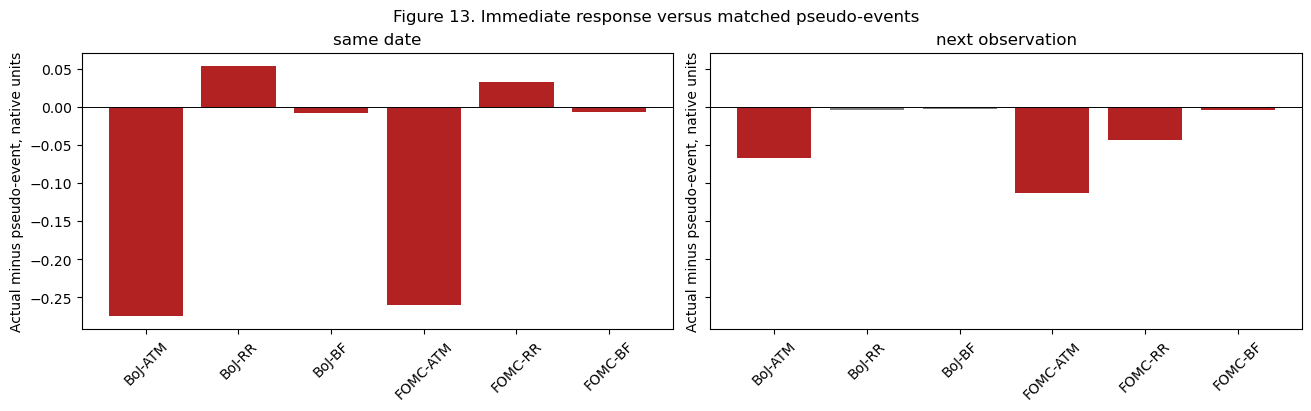

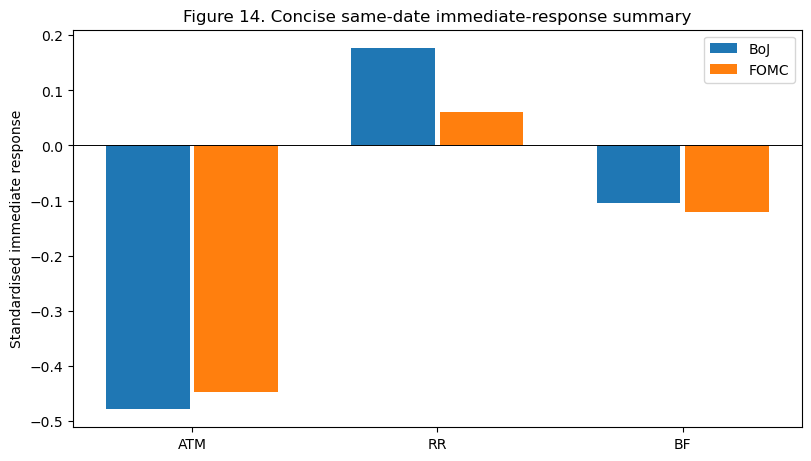

In [10]:
robust=[]
for bank in ['BoJ','FOMC']:
 for key in CHANNELS:
  z=event_study_summary.query("record_type=='estimand' and bank==@bank and channel==@key and estimand=='immediate_0' and sample=='all_complete'").set_index('alignment'); robust.append({'comparison_type':'same_date versus next_observation immediate response','bank':bank,'channel':key,'sample':'all_complete','same_date':float(z.loc['same_date','standardised_estimate']),'next_observation':float(z.loc['next_observation','standardised_estimate']),'difference':float(z.loc['same_date','standardised_estimate']-z.loc['next_observation','standardised_estimate']),'classification':'same sign' if np.sign(z.loc['same_date','standardised_estimate'])==np.sign(z.loc['next_observation','standardised_estimate']) else 'sign changes'})
  for alignment in ALIGNMENTS:
   q=event_study_summary.query("record_type=='estimand' and bank==@bank and channel==@key and estimand=='immediate_0' and alignment==@alignment").set_index('sample'); robust.append({'comparison_type':'all complete versus common period','bank':bank,'channel':key,'sample':alignment,'same_date':float(q.loc['all_complete','standardised_estimate']),'next_observation':float(q.loc['common_period','standardised_estimate']),'difference':float(q.loc['all_complete','standardised_estimate']-q.loc['common_period','standardised_estimate']),'classification':'sample sensitivity descriptive'})
robustness_summary=pd.DataFrame(robust)
q=placebo_results.query("sample=='all_complete' and estimand=='immediate_0'"); fig,axes=plt.subplots(1,2,figsize=(13,4),sharey=True,constrained_layout=True)
for ax,alignment in zip(axes,ALIGNMENTS):
 z=q.loc[q.alignment.eq(alignment)]; ax.bar(np.arange(len(z)),z.actual_minus_placebo,color=['firebrick' if x else 'grey' for x in z.bh_significant_5pct]); ax.axhline(0,color='black',lw=.7); ax.set(title=alignment.replace('_',' '),xticks=np.arange(len(z)),xticklabels=[r.bank+'-'+r.channel for r in z.itertuples()],ylabel='Actual minus pseudo-event, native units'); ax.tick_params(axis='x',rotation=45)
fig.suptitle('Figure 13. Immediate response versus matched pseudo-events'); fig.savefig(FIG/'figure_13_placebo_comparison.png',dpi=160,bbox_inches='tight'); display(fig); plt.close(fig)
q=event_study_summary.query("record_type=='estimand' and estimand=='immediate_0' and sample=='all_complete' and alignment=='same_date'"); fig,ax=plt.subplots(figsize=(8,4.5),constrained_layout=True)
for i,bank in enumerate(['BoJ','FOMC']):
 z=q.loc[q.bank.eq(bank)].set_index('channel').reindex(['ATM','RR','BF']); ax.bar(np.arange(3)+i*.36,z.standardised_estimate,width=.34,label=bank)
ax.axhline(0,color='black',lw=.7); ax.set(xticks=np.arange(3)+.18,xticklabels=['ATM','RR','BF'],ylabel='Standardised immediate response',title='Figure 14. Concise same-date immediate-response summary'); ax.legend(); fig.savefig(FIG/'figure_14_final_results_summary.png',dpi=160,bbox_inches='tight'); display(fig); plt.close(fig)


## 11. Main findings and limitations

The final tables and figures are interpreted as event-associated statistical evidence, not structural causal effects or known event weights. The comparison keeps the identical three-way complete-case panel, both alignment conventions, matched contiguous pseudo-event windows, and separate contemporaneous versus non-zero-lag TDMI evidence. Any apparent channel ordering is described as predictive lead-lag asymmetry only and is assessed against the matched pseudo-event context.


## 12. Final interpretation

ATM exhibits the clearest immediate event-associated response. RR and BF responses are smaller and less stable, and several estimates change sign under the alternative daily alignment convention. The main (-5 to +5) context-preserving TDMI comparison finds no BH-supported non-zero-lag peak for any of the three unordered channel pairs under either alignment; matched pseudo-event windows have related, and generally larger, descriptive peak dependence. The 0 to +5, -10 to +5, and ten-observation-block results are robustness checks only.

The option channels show contemporaneous nonlinear dependence, but lag-zero TDMI is not directional. Together with the null chronological Granger interaction results, corrected non-zero-lag TDMI does not establish a reproducible event-specific ordering across ATM, skew, and curvature. These diagnostics do not prove structural causality or support a separate multichannel forecasting notebook without a new leakage-safe forecasting design and stable out-of-sample results.


In [11]:
all_figures=sorted(FIG.glob('figure_*.png')); expected_figure_names=[f'figure_{i}_' for i in range(1,15)]; assert len(all_figures)==14 and all(x.stat().st_size>0 for x in all_figures) and all(any(x.name.startswith(prefix) for x in all_figures) for prefix in expected_figure_names)
assert not cross_channel_dependence.empty and cross_channel_dependence.query("method=='correlation'").statistic.notna().any(); assert not cross_channel_dependence.query("method=='tdmi_nonzero_peak'").empty
assert cross_channel_dependence.query("method=='tdmi_nonzero_peak'").overall_peak_lag.ne(0).all(); assert cross_channel_dependence.query("method=='tdmi_contemporaneous'").groupby(['alignment','context','window','block_length']).size().eq(3).all(); assert cross_channel_dependence.bh_q_value.dropna().between(0,1).all(); assert cross_channel_dependence.query("method.str.startswith('tdmi')",engine='python').p_value.between(0,1).all(); assert panel.date.is_unique and panel[list(CHANNELS.values())].notna().all().all(); assert all(len(selected_events(a,b,'all_complete'))>0 for a in ALIGNMENTS for b in ['BoJ','FOMC'])
seed_logic_source=str(PAIR_SEED_OFFSETS)+str(CONTEXT_SEED_OFFSETS); assert FORBIDDEN_HASH_TOKEN not in seed_logic_source and all(isinstance(x,int) for x in list(PAIR_SEED_OFFSETS.values())+list(CONTEXT_SEED_OFFSETS.values()))
assert set(cross_channel_dependence.query("method.str.startswith('tdmi')",engine='python').pair.dropna())=={'ATM-RR','ATM-BF','RR-BF'}; assert cross_channel_dependence.query("method=='tdmi_nonzero_peak'").source_bins.notna().all(); assert cross_channel_dependence.query("method=='tdmi_nonzero_peak'").effective_sample_size.gt(9).all()
assert all(np.all(np.diff(seg)==1) and np.unique(spec['segment_id'][seg]).size==1 for spec in context_specs for seg in spec['segments']); FIGURE_EXECUTION_ORDER=[f'figure_{i}_' for i in range(1,15)]; assert all(any(x.name.startswith(prefix) for x in all_figures) for prefix in FIGURE_EXECUTION_ORDER)
phase=[]
for bank in ['BoJ','FOMC']:
 q=event_study_summary.query("record_type=='estimand' and bank==@bank and sample=='all_complete' and estimand=='immediate_0'"); values=[]
 for alignment in ALIGNMENTS:
  z=q.loc[q.alignment.eq(alignment)].set_index('channel'); values.append(alignment+': ATM={:.3f}, RR={:.3f}, BF={:.3f} SD'.format(z.loc['ATM','standardised_estimate'],z.loc['RR','standardised_estimate'],z.loc['BF','standardised_estimate']))
 phase.append({'topic':bank+' event-associated response','finding':'; '.join(values)})
for alignment in ALIGNMENTS:
 q=primary_tdmi.loc[primary_tdmi.alignment.eq(alignment)]; actual=q.loc[q.context.eq('actual_event_windows')].set_index('pair'); pseudo=q.loc[q.context.eq('matched_pseudo_event_windows')].set_index('pair'); comparison='; '.join(f'{pair}: actual peak {actual.loc[pair,"overall_peak"]:.3f} (q={actual.loc[pair,"bh_q_value"]:.3f}), pseudo peak {pseudo.loc[pair,"overall_peak"]:.3f} (q={pseudo.loc[pair,"bh_q_value"]:.3f})' for pair in ['ATM-RR','ATM-BF','RR-BF']); phase.append({'topic':alignment+' main-window TDMI','finding':comparison+'; signed-lag evidence is descriptive and not an event-specific causal ordering.'})
phase += [{'topic':'joint multichannel response','finding':str(int(joint_response_tests.joint_permutation_supported_5pct.sum()))+' BH-supported Hotelling-type schedule-permutation tests out of '+str(len(joint_response_tests))+'.'},{'topic':'alignment sensitivity','finding':str(int(robustness_summary.classification.eq('sign changes').sum()))+' immediate-response bank-channel comparisons change sign across alignments.'},{'topic':'forecasting extension','finding':'Not justified automatically: context-preserving TDMI and chronological Granger diagnostics do not establish stable event-specific channel ordering.'}]
phase17_summary=pd.DataFrame(phase)
for name,frame in {'data_audit_summary.csv':data_audit_summary,'multichannel_panel_summary.csv':multichannel_panel_summary,'pairwise_overlap_summary.csv':pairwise_overlap_summary,'event_study_summary.csv':event_study_summary,'placebo_results.csv':placebo_results,'placebo_matching_quality.csv':placebo_matching_quality,'joint_response_tests.csv':joint_response_tests,'cross_channel_dependence.csv':cross_channel_dependence,'robustness_summary.csv':robustness_summary,'phase17_summary.csv':phase17_summary}.items(): frame.to_csv(OUT/name,index=False)
manifest={'notebook_name':'17_multichannel_fx_options_event_response.ipynb','creation_timestamp_utc':datetime.now(timezone.utc).isoformat(),'input_files':{'notebook14_panel':'notebook14_results/usdjpy_daily_spot_1m_atm_panel.csv','notebook14_events':'notebook14_results/central_bank_decisions_clean.csv','ATM':P['atm'].name,'RR':P['rr'].name,'BF':P['bf'].name},'selected_sheets_and_tickers':{k:{'sheet':v[1],'ticker':v[3]} for k,v in selected.items()},'units':'Native Bloomberg quote/volatility-point units; standardised effects use common-panel change standard deviations.','rr_sign_convention':'Not independently established from workbook metadata.','alignments':ALIGNMENTS,'event_window':[-20,10],'sequencing_windows':WINDOWS,'lag_convention':'For TDMI pair X-Y, +k compares X[t-k] with Y[t]; -k indicates Y preceding X. Zero lag is contemporaneous only.','draw_counts':{'event_bootstrap':BOOTSTRAPS,'pseudo_event_placebo':PLACEBO_DRAWS,'joint_schedule_permutations':JOINT_PERMUTATIONS,'tdmi_surrogates':TDMI_PERMUTATIONS},'seeds':SEEDS,'tdmi_reproducibility':{'pair_seed_offsets':{a+'-'+b:v for (a,b),v in PAIR_SEED_OFFSETS.items()},'context_seed_offsets':CONTEXT_SEED_OFFSETS,'requested_bins':TDMI_REQUESTED_BINS,'actual_bin_count_logic':'unique observed-context quantile edges; at least two usable bins','nonzero_lags':NONZERO_LAGS.tolist(),'main_window':'-5 to +5','robust_windows':['0 to +5','-10 to +5'],'main_block_length':TDMI_MAIN_BLOCK_LENGTH,'robust_block_length':TDMI_ROBUST_BLOCK_LENGTH,'surrogate_null':'within-context fixed-block permutation of source codes; event and pseudo-event windows are segmented, blocks never cross windows, short one-block windows use an individual-observation fallback','BH_families':'within alignment, context, window, method and block length across the three unordered TDMI pairs'},'BH_families':'placebo by alignment/sample/estimand; joint by alignment/sample; Granger by alignment/context/window; TDMI zero and nonzero separately by alignment/context/window/block length across three unordered pairs.','outputs':['data_audit_summary.csv','multichannel_panel_summary.csv','pairwise_overlap_summary.csv','event_study_summary.csv','placebo_results.csv','placebo_matching_quality.csv','joint_response_tests.csv','cross_channel_dependence.csv','robustness_summary.csv','phase17_summary.csv','manifest.json'],'figures':[x.name for x in all_figures],'limitations':['Event-response, Granger-style, and TDMI findings are predictive/statistical rather than structural causal evidence.','Daily alignment uncertainty is retained through both conventions.','No forecasting is implemented.']}
(OUT/'manifest.json').write_text(json.dumps(manifest,indent=2),encoding='utf-8')
expected={'data_audit_summary.csv','multichannel_panel_summary.csv','pairwise_overlap_summary.csv','event_study_summary.csv','placebo_results.csv','placebo_matching_quality.csv','joint_response_tests.csv','cross_channel_dependence.csv','robustness_summary.csv','phase17_summary.csv','manifest.json','figures'}; assert {x.name for x in OUT.iterdir()}==expected
display(Markdown('### Phase 17 summary')); display(phase17_summary); print('Notebook 17 cells={}, common-panel observations={}, event-study rows={}, placebo rows={}, joint rows={}, dependence rows={}, figures={}; captured warnings={}.'.format(24,len(panel),len(event_study_summary),len(placebo_results),len(joint_response_tests),len(cross_channel_dependence),len(all_figures),len(warning_records))); print('Notebook 17 complete. Event-response transmission was evaluated without forecasting or structural-causality claims.')


### Phase 17 summary

,topic,finding
0,BoJ event-associated response,"same_date: ATM=-0.479, RR=0.177, BF=-0.104 SD;..."
1,FOMC event-associated response,"same_date: ATM=-0.448, RR=0.060, BF=-0.121 SD;..."
2,same_date main-window TDMI,"ATM-RR: actual peak 0.014 (q=0.999), pseudo pe..."
3,next_observation main-window TDMI,"ATM-RR: actual peak 0.013 (q=0.999), pseudo pe..."
4,joint multichannel response,0 BH-supported Hotelling-type schedule-permuta...
5,alignment sensitivity,4 immediate-response bank-channel comparisons ...
6,forecasting extension,Not justified automatically: context-preservin...


Notebook 17 cells=24, common-panel observations=5878, event-study rows=1554, placebo rows=144, joint rows=14, dependence rows=234, figures=14; captured warnings=0.
Notebook 17 complete. Event-response transmission was evaluated without forecasting or structural-causality claims.
